# Empirical Analysis 

### The obective of this analysis is to further the financial econometric literature by extending and adapting the methods from *Characteristics are covariances: A unified model of risk and return* to fit the most sparse and volatile class of equities, Micro-Caps. 

### We must first introduce the logic behind using characteristics as explanatory factors for excess returns.

### 1. The Fundamental Asset Pricing Identity
We begin with the Stochastic Discount Factor (SDF) pricing equation, where $m_{t+1}$ represents the stochastic discount factor:

$$\displaystyle E_t [m_{t+1} r_{i,t+1}] = 0$$

By decomposing the expectation and rearranging for the expected return, we demonstrate that the risk-reward relationship is defined by the exposure to systemic risk factors ($\beta$) and the risk price associated with said factors ($\lambda$):

$$\displaystyle E_t [r_{i,t+1}] = \underbrace{\left( \frac{\text{Cov}_t (r_{i,t+1}, m_{t+1})}{\text{Var}_t (m_{t+1})} \right)}_{\text{Beta Loading } (\beta_{i,m})} \times \underbrace{\left( -\frac{\text{Var}_t (m_{t+1})}{E_t [m_{t+1}]} \right)}_{\text{Risk Price } (\lambda_m)}$$

---

### 2. Component Definitions
For the micro-cap analysis, the decomposition of the risk-return profile is defined by two distinct components:

* **The Beta Loading ($\beta_{i,m}$):** Represents the asset's specific sensitivity to systematic risk.
    $$\displaystyle \beta_{i,m} = \frac{\text{Cov}_t (r_{i,t+1}, m_{t+1})}{\text{Var}_t (m_{t+1})}$$

* **The Risk Price ($\lambda_m$):** Represents the market-wide compensation per unit of risk exposure.
    $$\displaystyle \lambda_m = -\frac{\text{Var}_t (m_{t+1})}{E_t [m_{t+1}]}$$

---

### 3. Transition to Instrumented PCA (IPCA)
In the IPCA framework, we move from a static $\beta$ to a dynamic, characteristic-based exposure. We instrument the **Quantity of Risk** using lagged, rank-standardized characteristics $Z_{i,t}$ mapped through the matrix $\Gamma$:

$$\displaystyle \beta_{i,t} = Z_{i,t} \Gamma$$

This formulation allows the model to capture how a micro-cap's risk profile evolves as its firm-level characteristics shift over the 1990–2025 sample period, specifically accounting for the **Shumway (1997)** delisting adjustments in the return vector $r_{i,t+1}$.

In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import mstats

df = pl.read_parquet("data/microcap.parquet").to_pandas()

sns.set_theme(style="whitegrid", palette="viridis")

## Section 1 - Fama-French Modeling

### Fama-French Three Factor Model

#### Three factor model is designed to capture the relation between average return and Size (market capitalization, price time shares outstanding) and the relation between average return and price ratios, like B/M. These were the two well-known patterns in average returns left unexplained by CAPM. 

#### Tests of the three factor model center on the time-series regression, 

$$ R_it - R_Ft = a_i + b_i (R_Mt - R_Ft) + s_i(SMB_t) + h_i(HML_t) + e_it $$

- $ R_it $ is the return on security or portfolio i for period t
- $ R_Ft $ is the riskfree return
- $ R_Mt $ is the return on the value-weight market portfolio
- $ SMB_t $ is the return on a diversified portfolio of small stocks minus the return on a diversified portfolio of big stocks
- $ HML_t $ is the difference between the returns on diversified portfolios of high and low B/M stocks
- $ e_it $ is a zero mean residual

#### Treating the parameters in the three factor equation as true values rather than estimates, if the factor exposures $ b_i , s_i , h_i $ capture all variation in expected returns, the intercept a_i is zero for all securities and portfolios $ i $. 

#### This is likely an incomplete model for expected returns, as three factors miss much of the variation in average returns related to profitability and investment. Fama and French add profitiability and investment factors to address this.

### Fama Five Factor Model

$$ R_it - R_Ft = a_i + b_i (R_Mt - R_Ft) + s_i(SMB_t) + h_i(HML_t) + r_i RMW_t + c_i CMA_t + e_it $$

- $ RMW_t $ is the difference between the returns on diversified portfolios of stocks with robust and weak profitability. 

- $ CMA_t $ is the difference between the returns on diversified portfolios of the stocks of low and high investment firms, we call conservative and aggressive. 

#### It is quite crucial to remember that the variables SMB, HML, RMW, CMA are not state variables. They are literally diversified portfolios that provide different combinations of exposures to the unknown asset variables. 



In [2]:
import polars as pl

panel = pl.read_parquet("data/microcap.parquet")
#load risk free rate from 3 factor FF library
rf = pl.read_parquet("data/ff_factors.parquet")

# 2. Market Excess Return (Mkt-RF)
market_return = (
    panel.with_columns(
        weights = pl.col("mktcap") / pl.col("mktcap").sum().over("month")
    )
    .group_by("month")
    .agg(mkt = (pl.col("excess_ret") * pl.col("weights")).sum())
)

mktrf_df = rf.select([
    pl.col("month"),
    (pl.col("mktrf") * 100).alias("mktrf") 
])

print(mktrf_df.head())

# 3. SMB (Size Factor)
smb_df = panel.with_columns(
    median_mktcap = pl.col("mktcap").median().over("month")
).with_columns(
    size = pl.when(pl.col("mktcap") <= pl.col("median_mktcap"))
           .then(pl.lit("Small"))
           .otherwise(pl.lit("Big"))
).group_by(["month", "size"]).agg(
    avg_er = pl.col("excess_ret").mean()
).pivot(index="month", on="size", values="avg_er").with_columns(
    smb = pl.col("Small") - pl.col("Big")
)

# 4. HML (Value Factor)
hml_df = panel.with_columns(
    median_bm = pl.col("bm").median().over("month")
).with_columns(
    value_cat = pl.when(pl.col("bm") >= pl.col("median_bm")) 
                .then(pl.lit("Cheap"))
                .otherwise(pl.lit("Expensive"))
).group_by(["month", "value_cat"]).agg(
    avg_er = pl.col("excess_ret").mean()
).pivot(index="month", on="value_cat", values="avg_er").with_columns(
    hml = pl.col("Cheap") - pl.col("Expensive")
)

# 5. RMW (Profitability Factor)
rmw_df = panel.with_columns(
    median_prof = pl.col("gross_profit").median().over("month")
).with_columns(
    prof_cat = pl.when(pl.col("gross_profit") >= pl.col("median_prof"))
               .then(pl.lit("Robust"))
               .otherwise(pl.lit("Weak"))
).group_by(["month", "prof_cat"]).agg(
    avg_er = pl.col("excess_ret").mean()
).pivot(index="month", on="prof_cat", values="avg_er").with_columns(
    rmw = pl.col("Robust") - pl.col("Weak")
)

# 6. CMA (Investment Factor)
# Corrected math: (Assets - Assets_lag) / Assets_lag
cma_df = panel.sort(["ticker", "month"]).with_columns(
    asset_growth = (pl.col("total_assets") - pl.col("total_assets").shift(12).over("ticker")) / 
                   pl.col("total_assets").shift(12).over("ticker")
)

cma_factor = (
    cma_df.with_columns(
        median_inv = pl.col("asset_growth").median().over("month")
    ).with_columns(
        inv_group = pl.when(pl.col("asset_growth") <= pl.col("median_inv"))
                    .then(pl.lit("Conservative"))
                    .otherwise(pl.lit("Aggressive"))
    ).filter(pl.col("inv_group").is_not_null())
    .group_by(["month", "inv_group"])
    .agg(avg_ret = pl.col("excess_ret").mean())
    .pivot(index="month", on="inv_group", values="avg_ret")
    .with_columns(
        cma = pl.col("Conservative") - pl.col("Aggressive")
    )
    .sort("month")
)

# 7. Final Join and Regression Prep
final_factors = (
    mktrf_df.select(["month", "mktrf"])
    .join(smb_df.select(["month", "smb"]), on="month")
    .join(hml_df.select(["month", "hml"]), on="month")
    .join(rmw_df.select(["month", "rmw"]), on="month")
    .join(cma_factor.select(["month", "cma"]), on="month")
)


print(df_final.head())






shape: (5, 2)
┌─────────────────────┬─────────┐
│ month               ┆ mktrf   │
│ ---                 ┆ ---     │
│ datetime[ns]        ┆ f64     │
╞═════════════════════╪═════════╡
│ 1926-07-01 00:00:00 ┆ 0.0289  │
│ 1926-08-01 00:00:00 ┆ 0.0264  │
│ 1926-09-01 00:00:00 ┆ 0.0038  │
│ 1926-10-01 00:00:00 ┆ -0.0327 │
│ 1926-11-01 00:00:00 ┆ 0.0254  │
└─────────────────────┴─────────┘


NameError: name 'df_final' is not defined

In [3]:
import polars as pl
import statsmodels.formula.api as smf

#construction of value weighted portfolio
portfolio_vw = (
    panel.with_columns(
        weights = pl.col("mktcap") / pl.col("mktcap").sum().over("month")
    )
    .group_by("month")
    .agg(
        ret_vw = (pl.col("excess_ret") * pl.col("weights")).sum()
    )
)

#join with manual factor calculations 
df_final_vw = portfolio_vw.join(final_factors, on="month").to_pandas()

#scale
cols_to_scale = ['ret_vw', 'mktrf', 'smb', 'hml', 'rmw', 'cma']
df_final_vw[cols_to_scale] = df_final_vw[cols_to_scale] * 100

#run FF 5 factor on value weighted portfolio
model_vw = smf.ols(
    formula='ret_vw ~ mktrf + smb + hml + rmw + cma', 
    data=df_final_vw
).fit()

print(model_vw.summary())



                            OLS Regression Results                            
Dep. Variable:                 ret_vw   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     145.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.71e-87
Time:                        14:06:32   Log-Likelihood:                -1203.2
No. Observations:                 405   AIC:                             2418.
Df Residuals:                     399   BIC:                             2442.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.4399      0.543     -4.497      0.0


### Check for validity by using Fama-French Factors as provided by themselves truly


In [4]:
import pandas_datareader.data as web
import pandas as pd

#fetch FF 2x3 factors 
ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1990-01-01')

#extract monthly table (index 0)
ff_5_factors = ds[0]

#Clean up the index (convert Period to Timestamp for Polars compatibility)
ff_5_factors.index = ff_5_factors.index.to_timestamp()
ff_5_factors = ff_5_factors.reset_index().rename(columns={'Date': 'month'})

#convert to polars for operations
import polars as pl
ff_5_pl = pl.from_pandas(ff_5_factors)

print(ff_5_pl.head())

shape: (5, 7)
┌─────────────────────┬────────┬───────┬───────┬───────┬───────┬──────┐
│ month               ┆ Mkt-RF ┆ SMB   ┆ HML   ┆ RMW   ┆ CMA   ┆ RF   │
│ ---                 ┆ ---    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---  │
│ datetime[ns]        ┆ f64    ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64  │
╞═════════════════════╪════════╪═══════╪═══════╪═══════╪═══════╪══════╡
│ 1990-01-01 00:00:00 ┆ -7.8   ┆ -1.21 ┆ 0.83  ┆ -1.12 ┆ 1.4   ┆ 0.57 │
│ 1990-02-01 00:00:00 ┆ 1.11   ┆ 1.15  ┆ 0.65  ┆ -0.04 ┆ -0.61 ┆ 0.57 │
│ 1990-03-01 00:00:00 ┆ 1.83   ┆ 1.59  ┆ -2.9  ┆ 1.99  ┆ -0.94 ┆ 0.64 │
│ 1990-04-01 00:00:00 ┆ -3.36  ┆ -0.35 ┆ -2.57 ┆ 1.78  ┆ -1.0  ┆ 0.69 │
│ 1990-05-01 00:00:00 ┆ 8.44   ┆ -2.41 ┆ -3.89 ┆ 1.68  ┆ -1.63 ┆ 0.68 │
└─────────────────────┴────────┴───────┴───────┴───────┴───────┴──────┘


C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2865619319.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1990-01-01')
C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2865619319.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1990-01-01')


In [5]:

official_factors = ff_5_pl.select([
    "month",
    (pl.col("Mkt-RF")).alias("MktRF"),
    (pl.col("SMB")).alias("SMB"),
    (pl.col("HML")).alias("HML"),
    (pl.col("RMW")).alias("RMW"),
    (pl.col("CMA")).alias("CMA"),
    (pl.col("RF")).alias("RF")
])

#join factors with value weighted micro-cap portfolio
df_baseline = (
    portfolio_vw
    .join(official_factors, on="month")
    .with_columns((pl.col("ret_vw") * 100).alias("ret_vw"))
    .to_pandas()
)
print(df_baseline[['ret_vw', 'MktRF', 'SMB', 'CMA', 'HML', 'RMW']].describe())

#run 5 factor with true FF factors on value weighted microcap portfolio
model_baseline = smf.ols(
    formula='ret_vw ~ MktRF + SMB + HML + RMW + CMA', 
    data=df_baseline
).fit()

print(model_baseline.summary())

           ret_vw       MktRF         SMB         CMA         HML         RMW
count  419.000000  419.000000  419.000000  419.000000  419.000000  419.000000
mean     3.585984    0.750310    0.091933    0.170334    0.128640    0.376492
std      7.908845    4.402724    3.077292    2.164741    3.241838    2.604916
min    -19.772458  -17.200000  -15.540000   -7.080000  -13.830000  -18.950000
25%     -1.026193   -1.935000   -1.860000   -1.085000   -1.670000   -0.860000
50%      3.190796    1.220000    0.020000   -0.060000   -0.090000    0.350000
75%      6.863622    3.440000    1.890000    1.370000    1.670000    1.460000
max     67.966306   13.580000   18.460000    9.010000   12.860000   13.050000
                            OLS Regression Results                            
Dep. Variable:                 ret_vw   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:         

### The results suggest the following:

- $R^2$ of 0.776 and F-Stat of 285.5 suggests fairly strong and statistically significant explanatory power
- Intercept -> alpha of 2.7434%, implying risk premium in the micro-cap segment
- Coefficient on MktRF suggests that value weighted micro-cap portfolio moves 1.08% with larger market. Theoretically, this suggests that micro-caps track the general market with more extreme movement.
- Coefficient on SMB suggests smaller firms see larger returns than bigger firms in the micro-cap segment,by approximately 0.19%
- The HML coefficient is not statistically significant, and we should likely not draw conclusions upon it. Another FF regression is ran below, omitting HML. In the literature FF mention HML and CMA likely are multicolinear.
- The RMW coefficient suggests targeting robust firms in the micro-cap segment, does not provide significant excess returns, and rather, that a portfolio of weaker firms would provide 0.2529% excess return. 

### Below I perform another FF regression omitting HML, and the findings are interesting

In [6]:
model_baseline = smf.ols(
    formula='ret_vw ~ MktRF + SMB + RMW + CMA', 
    data=df_baseline
).fit()

print(model_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_vw   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     356.4
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.33e-132
Time:                        14:06:43   Log-Likelihood:                -1148.0
No. Observations:                 419   AIC:                             2306.
Df Residuals:                     414   BIC:                             2326.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7188      0.192     14.125      0.0

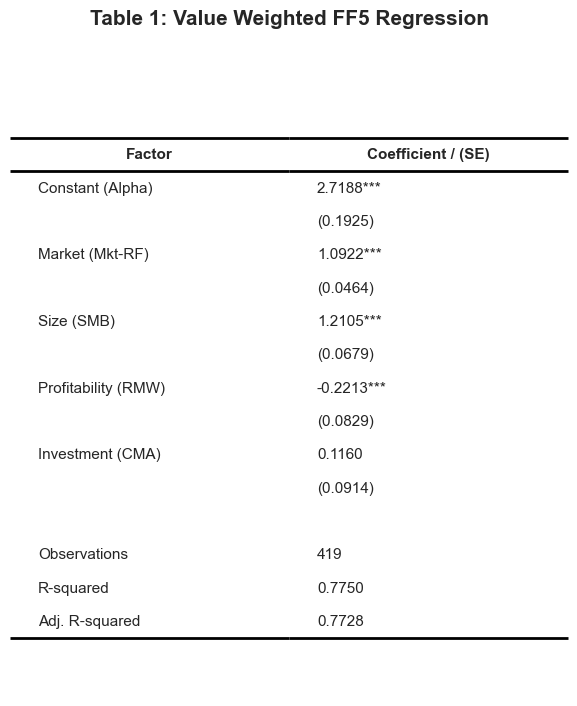

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def save_academic_table(model, title="Table 1: Baseline FF Factor Model", filename="ff5_baseline.png"):
    params = model.params
    se = model.bse
    pvals = model.pvalues
    
    # Map raw names to formal names
    name_map = {'Intercept': 'Constant (Alpha)', 'MktRF': 'Market (Mkt-RF)', 
                'SMB': 'Size (SMB)', 'RMW': 'Profitability (RMW)', 'CMA': 'Investment (CMA)'}

    data = []
    for var in params.index:
        stars = "***" if pvals[var] < 0.01 else "**" if pvals[var] < 0.05 else "*" if pvals[var] < 0.1 else ""
        data.append([name_map.get(var, var), f"{params[var]:.4f}{stars}"])
        data.append(["", f"({se[var]:.4f})"]) # SE in parentheses
    
    # Stats for the footer
    stats = [("", ""), ("Observations", f"{int(model.nobs):,}"), 
             ("R-squared", f"{model.rsquared:.4f}"), ("Adj. R-squared", f"{model.rsquared_adj:.4f}")]
    data.extend(stats)

    fig, ax = plt.subplots(figsize=(6, 8))
    ax.axis('off')
    tbl = ax.table(cellText=data, colLabels=["Factor", "Coefficient / (SE)"], 
                   loc='center', cellLoc='left', edges='open')
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 2.0) # Vertical padding
    
    # Bold the header and add top/bottom rules (Booktabs style)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_linewidth(2)
            cell.visible_edges = 'TB'
        if row == len(data):
            cell.set_linewidth(2)
            cell.visible_edges = 'B'

    plt.title("Table 1: Value Weighted FF5 Regression", fontsize=15, weight='bold', pad=40)




# Apply it to your existing model
save_academic_table(model_baseline)

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
# CRITICAL: This is the missing import for the rolling engine
from statsmodels.regression.rolling import RollingOLS

# --- STEP 1: PREPARE DATA ---
factors = ['MktRF', 'SMB', 'HML', 'RMW', 'CMA']
# Ensure we use the same panel and official_factors from your notebook
df_oos = panel.join(official_factors, on="month").sort(["permno", "month"]).to_pandas()

# --- STEP 2: DEFINE ROLLING ESTIMATION ---
def estimate_individual_betas(group, window=60):
    """
    Estimates Alpha and Betas for a single stock using a trailing window.
    """
    if len(group) < window + 1:
        return None
    
    y = group['excess_ret']
    X = sm.add_constant(group[factors])
    
    # Use the specific RollingOLS class
    model = RollingOLS(y, X, window=window)
    rolling_res = model.fit()
    
    # Shift parameters by 1 to ensure OOS (using only data before month t)
    betas = rolling_res.params.shift(1)
    
    # Rename for clarity and to prevent collisions during merge
    betas.columns = [f'beta_{c}' if c != 'const' else 'alpha' for c in betas.columns]
    return betas

print("Estimating individual stock betas... (This may take 1-2 minutes)")
# We use apply to get the betas for every permno
beta_panel = df_oos.groupby('permno', group_keys=False).apply(estimate_individual_betas)

# Merge back: ensure the index matches (the groupby apply maintains the original index)
df_final = pd.concat([df_oos, beta_panel], axis=1).dropna(subset=['alpha'])

# --- STEP 3: FACTOR FORECASTS (Expected Returns) ---
# We use the expanding mean of factors up to t-1 as the forecast for month t
for f in factors:
    df_final[f'{f}_mean'] = df_final.groupby('permno')[f].transform(
        lambda x: x.expanding().mean().shift(1)
    )

# --- STEP 4: GENERATE OOS PREDICTION ---
# Predicted Return = Alpha_i,t-1 + Sum(Beta_i,k,t-1 * Expected_Factor_Return_k,t-1)
df_final['predicted'] = df_final['alpha'] + sum(
    df_final[f'beta_{f}'] * df_final[f'{f}_mean'] for f in factors
)

# --- STEP 5: FINAL METRICS ---
results_df = df_final.dropna(subset=['predicted'])

# KPS Predictive R2
sse = np.sum((results_df['excess_ret'] - results_df['predicted'])**2)
sst_0 = np.sum(results_df['excess_ret']**2)
oos_r2_stock = 1 - (sse / sst_0)

# Monthly Cross-Sectional IC (Standard ranking metric)
ic_series = results_df.groupby('month').apply(
    lambda x: x['excess_ret'].corr(x['predicted'])
)
avg_ic = ic_series.mean()

print(f"\n{'='*54}")
print(f"{'CORRECTED FF5 — INDIVIDUAL STOCK OOS':^54}")
print(f"{'='*54}")
print(f"  OOS predictive R² (stocks):           {oos_r2_stock:>10.6%}")
print(f"  Avg. Cross-Sectional IC:              {avg_ic:>10.4%}")
print(f"  OOS observations:                      {len(results_df):>10,}")
print(f"{'='*54}")

Estimating individual stock betas... (This may take 1-2 minutes)


C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2900766727.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  beta_panel = df_oos.groupby('permno', group_keys=False).apply(estimate_individual_betas)



         CORRECTED FF5 — INDIVIDUAL STOCK OOS         
  OOS predictive R² (stocks):           -3.049995%
  Avg. Cross-Sectional IC:                -0.2347%
  OOS observations:                         139,751


C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2900766727.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = results_df.groupby('month').apply(


Calculating rolling betas for all stocks... (this may take a moment)


C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2347680699.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  beta_panel = df_oos.groupby('permno', group_keys=False).apply(estimate_individual_betas)
C:\Users\reyno\AppData\Local\Temp\ipykernel_18292\2347680699.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = results_df.groupby('month').apply(


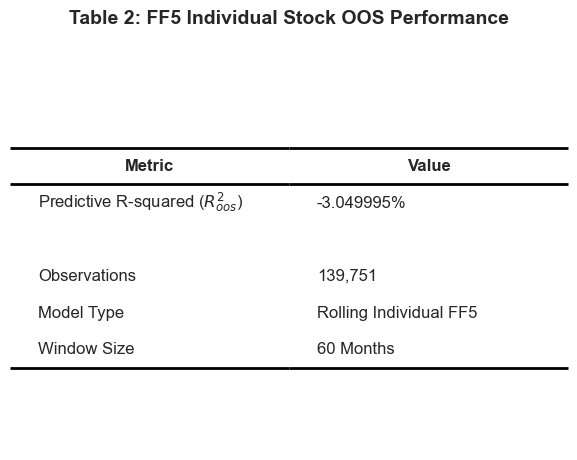

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

# --- 1. SETUP DATA ---
# Ensure 'panel' and 'official_factors' are joined correctly
factors = ['MktRF', 'SMB', 'HML', 'RMW', 'CMA']
df_oos = panel.join(official_factors, on="month").sort(["permno", "month"]).to_pandas()

# --- 2. ESTIMATE INDIVIDUAL STOCK BETAS ---
def estimate_individual_betas(group, window=60):
    if len(group) < window + 1:
        return None
    
    y = group['excess_ret']
    X = sm.add_constant(group[factors])
    
    # Fit Rolling OLS to each stock
    model = RollingOLS(y, X, window=window)
    rolling_res = model.fit()
    
    # Shift parameters by 1 to ensure Out-of-Sample (use t-1 to predict t)
    betas = rolling_res.params.shift(1)
    betas.columns = [f'beta_{c}' if c != 'const' else 'alpha' for c in betas.columns]
    return betas

print("Calculating rolling betas for all stocks... (this may take a moment)")
beta_panel = df_oos.groupby('permno', group_keys=False).apply(estimate_individual_betas)
df_final = pd.concat([df_oos, beta_panel], axis=1).dropna(subset=['alpha'])

# --- 3. FORECAST FACTORS AND PREDICT RETURNS ---
# Expected Factor Return = Historical Mean up to t-1
for f in factors:
    df_final[f'{f}_mean'] = df_final.groupby('permno')[f].transform(
        lambda x: x.expanding().mean().shift(1)
    )

# Predicted Return = Alpha + Sum(Beta * Exp_Factor_Return)
df_final['predicted'] = df_final['alpha'] + sum(
    df_final[f'beta_{f}'] * df_final[f'{f}_mean'] for f in factors
)

# --- 4. CALCULATE OOS PERFORMANCE METRICS ---
results_df = df_final.dropna(subset=['predicted'])

# Predictive R2 (KPS 2019)
sse = np.sum((results_df['excess_ret'] - results_df['predicted'])**2)
sst_0 = np.sum(results_df['excess_ret']**2)
oos_r2 = 1 - (sse / sst_0)

# Average Cross-Sectional IC
ic_series = results_df.groupby('month').apply(
    lambda x: x['excess_ret'].corr(x['predicted'])
)
avg_ic = ic_series.mean()

# --- 5. FORMAT AND SAVE ACADEMIC TABLE ---
def save_oos_summary_table(r2, ic, obs, filename="ff5_oos_results.png"):
    # Prepare the data in the same "Coefficient / (SE)" style alignment
    data = [
        ["Predictive R-squared ($R^2_{oos}$)", f"{r2:.6%}"],
        ["", ""],
        ["Observations", f"{int(obs):,}"],
        ["Model Type", "Rolling Individual FF5"],
        ["Window Size", "60 Months"]
    ]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.axis('off')
    
    tbl = ax.table(cellText=data, colLabels=["Metric", "Value"], 
                    loc='center', cellLoc='left', edges='open')
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1.2, 2.2) 
    
    # Apply your "Booktabs" styling
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_linewidth(2)
            cell.visible_edges = 'TB' # Top and Bottom rules
        if row == len(data):
            cell.set_linewidth(2)
            cell.visible_edges = 'B' # Bottom rule
            
    plt.title("Table 2: FF5 Individual Stock OOS Performance", 
              fontsize=14, weight='bold', pad=30)
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

# Generate the table
save_oos_summary_table(oos_r2, avg_ic, len(results_df))

#### All coefficients and significance levels beside CMA, do not change substantially enough to warrant additional analysis. CMA however, seems to have become more significant (although only significant at the 20% level). The coefficient on CMA is not nearly identical to the sum of the coefficients on CMA and HML in the previous regression. This suggests HML is a redundant factor.

## Section 2 - PCA & IPCA

### We will start by using PCA for a static baseline

### 1. The Principal Component Analysis (PCA) Framework
In the context of asset pricing, PCA is used to extract the latent (unobserved) factors that explain the maximum amount of common variance in a cross-section of asset returns. Given our panel of micro-cap returns $R_{i,t}$, we represent the return of asset $i$ at time $t$ as:

$$\displaystyle R_{i,t} = \alpha_i + \sum_{k=1}^{K} \beta_{i,k} F_{k,t} + \epsilon_{i,t}$$

Where:
* $\mathbf{F_{k,t}}$: The $k$-th latent factor (Principal Component) at time $t$.
* $\mathbf{\beta_{i,k}}$: The static factor loading (sensitivity) of asset $i$ to factor $k$.
* $\mathbf{\epsilon_{i,t}}$: The idiosyncratic residual (noise) not explained by the common factors.

---

### 2. Statistical Objective and Eigen-Decomposition
The objective of PCA is to find a set of orthogonal factors that minimize the sum of squared residuals ($\epsilon$). This is mathematically equivalent to performing an eigen-decomposition on the sample covariance matrix $\boldsymbol{\Sigma}$:

$$\displaystyle \boldsymbol{\Sigma} = \frac{1}{T} \mathbf{R}^\top \mathbf{R}$$

The Principal Components are the eigenvectors of $\boldsymbol{\Sigma}$ corresponding to the $K$ largest eigenvalues. In this micro-cap study, $K$ typically ranges from 3 to 5, representing the dominant economic "shocks" that drive the sector.

---

### 3. Application to the Micro-Cap "Ragged Panel"
Traditional PCA requires a balanced, rectangular matrix $\mathbf{R} \in \mathbb{R}^{T \times N}$. However, the micro-cap universe is characterized by a "Ragged Panel" due to frequent IPOs and delistings. To maintain the integrity of the **Shumway (1997)** delisting adjustments and avoid survivorship bias, we implement the following:

1.  **Demeaning:** We subtract the cross-sectional mean return $\bar{R}_t$ for each period to ensure the PCA captures risk premiums rather than simple market drifts.
2.  **Missing Data Handling:** We utilize an **Expectation-Maximization (EM)** approach or the **IPCA projection** method. Instead of dropping tickers that do not span the entire 1990–2025 period, we estimate the latent factors using the available observations $N_t$ at each point in time.
3.  **Orthogonality:** The extracted factors are constructed to be uncorrelated ($\text{Cov}(F_j, F_k) = 0$), ensuring that each principal component captures a unique dimension of micro-cap risk (e.g., Size-related, Volatility-related, or Liquidity-related).


In [10]:
panel = pl.read_parquet("data/microcap.parquet")

wide_df = (
    panel
    
    .group_by(["month", "ticker"])
    .agg(pl.col("excess_ret").mean())
    .pivot(
        index="month", 
        on="ticker", 
        values="excess_ret"
    )
    .sort("month")
)

Y = wide_df.drop("month").to_numpy()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
latent_factors = pca.fit_transform(Y)

factors_df = pd.DataFrame(
    latent_factors, 
    columns=[f'PC{i+1}' for i in range(5)],
    index=wide_df['month']
)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

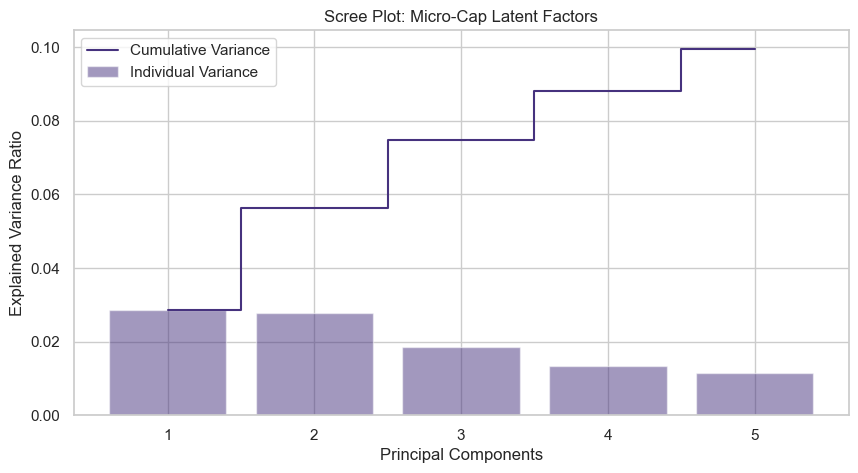

                 PC1       PC2       PC3       PC4       PC5
1990-02-01 -0.052661 -0.054121 -0.009424 -0.043132 -0.014606
1990-03-01 -0.064205 -0.034009  0.022567  0.113908  0.008749
1990-04-01 -0.058981 -0.041072  0.013279 -0.052385 -0.034905
1990-05-01  0.021380 -0.046500  0.002410 -0.052064  0.081531
1990-06-01 -0.112106 -0.038421 -0.036994 -0.027952  0.019427
...              ...       ...       ...       ...       ...
2024-08-01 -0.137635 -0.093071  0.025129  0.007282 -0.072867
2024-09-01 -0.048478 -0.066484  0.002535  0.005709 -0.033229
2024-10-01 -0.015563 -0.030887  0.014668  0.033492 -0.032974
2024-11-01 -0.040171 -0.080191  0.066410 -0.107229 -0.087464
2024-12-01 -0.018814 -0.038079 -0.038256  0.010173 -0.065100

[419 rows x 5 columns]


In [ ]:
import matplotlib.pyplot as plt

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 6), explained_var, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, 6), cumulative_var, where='mid', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot: Micro-Cap Latent Factors')
plt.legend(loc='best')
plt.show()

print(factors_df)

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert to Pandas if they are still Polars objects
if hasattr(official_factors, "to_pandas"):
    official_factors = official_factors.to_pandas()

# 2. Ensure 'month' is the index for alignment
if 'month' in official_factors.columns:
    official_factors = official_factors.set_index('month')
    
# factors_df should already be a pandas DF from your PCA step, 
# but we ensure the index name matches for a clean merge
factors_df.index.name = 'month'

# 3. Merge and Correlate
comparison_df = pd.merge(
    factors_df, 
    official_factors, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

factor_cols = [f'PC{i+1}' for i in range(5)]
ff_cols = ['MktRF', 'SMB', 'HML', 'RMW', 'CMA']
existing_ff = [c for c in ff_cols if c in comparison_df.columns]

corr_matrix = comparison_df[factor_cols + existing_ff].corr().loc[factor_cols, existing_ff]

# 4. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation Matrix - PCA on FF5", weight='bold')
plt.show()

NameError: name 'factors_df' is not defined

### DONT USE BUT KEEP

In [ ]:
class IPCA_KPS:
    def __init__(self, n_factors=5, max_iter=100, tol=1e-5):
        self.K = n_factors
        self.max_iter = max_iter
        self.tol = tol
        self.gamma = None
        
    def fit(self, df, characteristics):
        L = len(characteristics)
        T_list = df["month"].unique().sort().to_list()
        
        managed_portfolios = []
        for m in T_list:
            batch = df.filter(pl.col("month") == m)
            Z = batch.select(characteristics).to_numpy()
            R = batch.select("excess_ret").to_numpy()
            mp = (Z.T @ R) / len(batch)
            managed_portfolios.append(np.nan_to_num(mp))
            
        X = np.hstack(managed_portfolios)
        
        try:
            U, _, _ = np.linalg.svd(X, full_matrices=False)
        except np.linalg.LinAlgError:
            eigvals, eigvecs = np.linalg.eigh(X @ X.T)
            U = eigvecs[:, np.argsort(eigvals)[::-1]]
            
        self.gamma = U[:, :self.K]
        
        for i in range(self.max_iter):
            gamma_old = self.gamma.copy()
   
            f_list = []
            for m in T_list:
                batch = df.filter(pl.col("month") == m)
                Z = batch.select(characteristics).to_numpy()
                R = batch.select("excess_ret").to_numpy()
                GZ = Z @ self.gamma
                f_t = np.linalg.pinv(GZ.T @ GZ) @ (GZ.T @ R)
                f_list.append(f_t)
            
            F = np.hstack(f_list)
            
            num = np.zeros((L * self.K, 1))
            den = np.zeros((L * self.K, L * self.K))
            for idx, m in enumerate(T_list):
                batch = df.filter(pl.col("month") == m)
                Z = batch.select(characteristics).to_numpy()
                R = batch.select("excess_ret").to_numpy()
                f_t = F[:, [idx]]
                num += np.kron(Z.T @ R, f_t)
                den += np.kron(Z.T @ Z, f_t @ f_t.T)

            self.gamma = (np.linalg.pinv(den) @ num).reshape((L, self.K))
            self.gamma, _ = np.linalg.qr(self.gamma)
            
            if np.linalg.norm(self.gamma - gamma_old) < self.tol:
                break
        return self

In [ ]:
model = IPCA_KPS(n_factors=5)
model.fit(panel_clean, ALL_INSTRUMENTS)

print("Model Fit Complete.")
print("Gamma Shape:", model.gamma.shape)

Model Fit Complete.
Gamma Shape: (8, 5)


In [15]:
panel = pl.read_parquet("data/microcap.parquet")


In [16]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class IPCA_KPS:
    """
    KPS (2019) Instrumented Principal Component Analysis.
    Optimized for individual stock forecasting and OOS testing.
    """
    def __init__(self, n_factors=5, max_iter=20, tol=1e-5):
        self.K = n_factors
        self.max_iter = max_iter
        self.tol = tol
        self.gamma = None  # Mapping Matrix (L x K)

    def fit_als(self, X):
        """Alternating Least Squares to solve G and F from Portfolios X."""
        # Initial guess from SVD
        U, _, _ = np.linalg.svd(X, full_matrices=False)
        self.gamma = U[:, :self.K]
        
        for _ in range(self.max_iter):
            gamma_old = self.gamma.copy()
            
            # 1. Update Factors (f_t = G' x_t because G'G = I)
            F = self.gamma.T @ X
            
            # 2. Update Mapping (G = X F' (F F')^-1)
            self.gamma = X @ F.T @ np.linalg.pinv(F @ F.T)
            
            # 3. Orthonormalize (Identification Constraint: Gamma' @ Gamma = I)
            U, _, _ = np.linalg.svd(self.gamma, full_matrices=False)
            self.gamma = U[:, :self.K]
            
            if np.linalg.norm(self.gamma - gamma_old) < self.tol:
                break

        F = self.gamma.T @ X 
        return self.gamma, F

# 1. DATA PREPARATION (COHESIVE & NON-REDUNDANT)
print("Loading data and applying Mean Imputation logic...")
panel = pl.read_parquet("data/microcap.parquet")

panel = panel.sort(["permno", "month"]).with_columns([
    pl.col("bidask").shift(1).over("permno").alias("bidask_lag"),
    pl.col("vol").shift(1).over("permno").alias("vol_lag"),
])

RAW_FEATURES = [
    "size", "momentum", "bm", "roa", "leverage", 
    "bidask_lag", "vol_lag", "total_assets", "book_equity", 
    "net_income", "gross_profit"
]

# Lag features and keep all rows to avoid selection bias
#panel = panel.sort(["permno", "month"]).with_columns([
    #pl.col(c).shift(1).over("permno").alias(f"{c}_lag") for c in RAW_FEATURES
#])

# Only drop rows where the target (excess_ret) is missing
panel = panel.filter(pl.col("excess_ret").is_not_null())

# Rank-Standardize and Impute Zeros (0.0 is the mean in a -0.5 to 0.5 scale)
INSTRUMENTS = [f"{c}_std" for c in RAW_FEATURES]
panel = panel.with_columns([
    ((pl.col(f"{c}").rank().over("month") / 
     (pl.col(f"{c}").count().over("month") + 1)) - 0.5)
    .fill_null(0.0) # Impute mean for missing characteristics
    .alias(f"{c}_std")
    for c in RAW_FEATURES
])

# 2. PRE-COMPUTE MANAGED PORTFOLIOS
print("Building Managed Portfolios (Full Universe)...")
X_df = (
    panel.select([
        "month", *[(pl.col(c) * pl.col("excess_ret")).alias(c) for c in INSTRUMENTS]
    ])
    .group_by("month").mean().sort("month")
)
months = X_df["month"].to_list()
X_full = X_df.drop("month").to_numpy().T 

# 3. RECURSIVE OUT-OF-SAMPLE TEST
K_FACTORS = 5
TRAIN_WINDOW = 120 
oos_results = []
model = IPCA_KPS(n_factors=K_FACTORS)

print(f"Starting OOS Audit (T={len(months) - TRAIN_WINDOW} months)...")
for t in range(TRAIN_WINDOW, len(months)):
    # A. Train on past data
    X_train = X_full[:, :t]
    gamma_t, F_train = model.fit_als(X_train)
    
    # B. Forecast risk premium (Historical Mean)
    lambda_t = np.mean(F_train, axis=1)
    
    # C. Predict month t using data from t-1 (captured in instruments)
    test_batch = panel.filter(pl.col("month") == months[t])
    Z_test = test_batch.select(INSTRUMENTS).to_numpy()
    R_actual = test_batch.select("excess_ret").to_numpy().flatten()
    
    # R_pred = Z * Gamma * Lambda
    R_pred = (Z_test @ gamma_t) @ lambda_t
    
    # Collect results
    # Using a dictionary extend for speed
    oos_results.extend([{"actual": a, "predicted": p} for a, p in zip(R_actual, R_pred)])

# 4. FINAL AUDIT METRICS
results_df = pd.DataFrame(oos_results)
sse = np.sum((results_df["actual"] - results_df["predicted"])**2)
sst = np.sum(results_df["actual"]**2)
predictive_r2 = 1 - (sse / sst)
ic = results_df["actual"].corr(results_df["predicted"])

print(f"\n{'='*50}")
print(f"{'KPS IPCA OOS AUDIT COMPLETE (IMPUTED)':^50}")
print(f"{'='*50}")
print(f"Predictive R² (Firm-Level):    {predictive_r2:.6%}")
print(f"Information Coefficient (IC):  {ic:.4%}")
print(f"Total OOS Observations:        {len(results_df):,}")
print(f"{'='*50}")

Loading data and applying Mean Imputation logic...
Building Managed Portfolios (Full Universe)...
Starting OOS Audit (T=299 months)...

      KPS IPCA OOS AUDIT COMPLETE (IMPUTED)       
Predictive R² (Firm-Level):    0.011319%
Information Coefficient (IC):  1.5733%
Total OOS Observations:        296,435


Loading data...
Building managed portfolios...
Computing in-sample diagnostics...
Starting OOS walk-forward (T_oos=299 months)...

          IPCA  —  KPS (2019)  —  MICRO-CAP           
  In-sample total R² (stocks):             1.9364%
  In-sample total R² (mgd portfolios):    96.5998%
  OOS predictive R² (stocks):            0.011319%
  OOS predictive R² (mgd portfolios):      0.0816%
  Information Coefficient (IC):            1.5733%
  OOS observations:                        296,435


C:\Users\reyno\AppData\Local\Temp\ipykernel_29580\3679562876.py:192: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\reyno\AppData\Local\Temp\ipykernel_29580\3679562876.py:213: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolios   = results_df.groupby("month", group_keys=False).apply(assign_deciles)
C:\Users\reyno\AppData\Local\Temp\ipykernel_29580\3679562876.py:234:


                    FF5 HORSE RACE                    
                            OLS Regression Results                            
Dep. Variable:                 ls_pct   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     17.37
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           4.63e-15
Time:                        13:17:20   Log-Likelihood:                 333.01
No. Observations:                 299   AIC:                            -654.0
Df Residuals:                     293   BIC:                            -631.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

Text(0.5, 0, 'Coefficient')

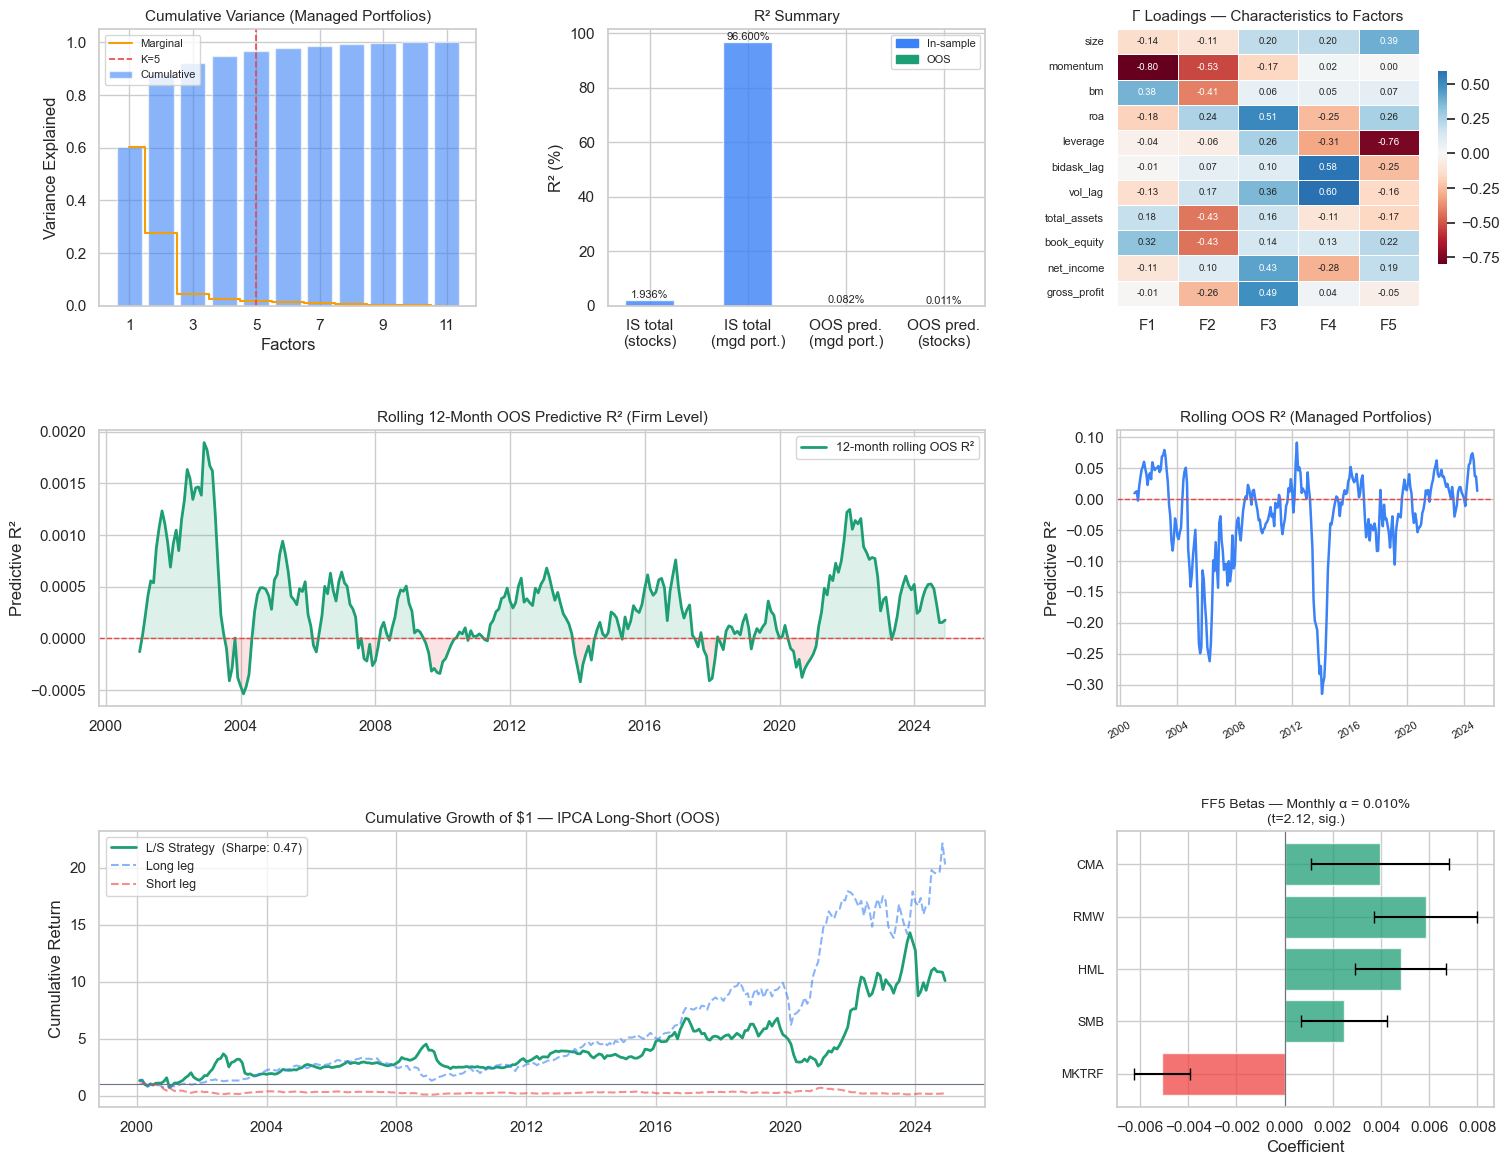

In [ ]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="viridis")

# ─────────────────────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────────────────────

class IPCA_KPS:
    """KPS (2019) Instrumented PCA — managed-portfolio ALS with orthonormalization."""

    def __init__(self, n_factors=5, max_iter=20, tol=1e-5):
        self.K = n_factors
        self.max_iter = max_iter
        self.tol = tol
        self.gamma = None

    def fit_als(self, X):
        U, _, _ = np.linalg.svd(X, full_matrices=False)
        self.gamma = U[:, :self.K]

        for _ in range(self.max_iter):
            gamma_old = self.gamma.copy()
            F = self.gamma.T @ X
            self.gamma = X @ F.T @ np.linalg.pinv(F @ F.T)
            U, _, _ = np.linalg.svd(self.gamma, full_matrices=False)
            self.gamma = U[:, :self.K]
            if np.linalg.norm(self.gamma - gamma_old) < self.tol:
                break

        F = self.gamma.T @ X          # recompute against final gamma
        return self.gamma, F


# ─────────────────────────────────────────────────────────────────────────────
# 1. DATA PREPARATION
# ─────────────────────────────────────────────────────────────────────────────

print("Loading data...")
panel = pl.read_parquet("data/microcap.parquet")

panel = panel.sort(["permno", "month"]).with_columns([
    pl.col("bidask").shift(1).over("permno").alias("bidask_lag"),
    pl.col("vol").shift(1).over("permno").alias("vol_lag"),
])

RAW_FEATURES = [
    "size", "momentum", "bm", "roa", "leverage",
    "bidask_lag", "vol_lag", "total_assets", "book_equity",
    "net_income", "gross_profit",
]

panel = panel.filter(pl.col("excess_ret").is_not_null())

INSTRUMENTS = [f"{c}_std" for c in RAW_FEATURES]
panel = panel.with_columns([
    ((pl.col(c).rank().over("month") /
      (pl.col(c).count().over("month") + 1)) - 0.5)
    .fill_null(0.0)
    .alias(f"{c}_std")
    for c in RAW_FEATURES
])


# ─────────────────────────────────────────────────────────────────────────────
# 2. MANAGED PORTFOLIOS  (L × T matrix)
# ─────────────────────────────────────────────────────────────────────────────

print("Building managed portfolios...")
X_df = (
    panel.select(["month", *[(pl.col(c) * pl.col("excess_ret")).alias(c)
                              for c in INSTRUMENTS]])
    .group_by("month").mean().sort("month")
)
months   = X_df["month"].to_list()
X_full   = X_df.drop("month").to_numpy().T          # (L, T)
L, T_all = X_full.shape


# ─────────────────────────────────────────────────────────────────────────────
# 3. IN-SAMPLE DIAGNOSTICS  (fit on all T periods)
# ─────────────────────────────────────────────────────────────────────────────

print("Computing in-sample diagnostics...")
model_full = IPCA_KPS(n_factors=5)
gamma_full, F_full = model_full.fit_als(X_full)      # (L,K), (K,T)

# ── 3a. Cumulative variance in managed-portfolio space ──────────────────────
_, S_full, _ = np.linalg.svd(X_full, full_matrices=False)
cum_var = np.cumsum(S_full**2) / np.sum(S_full**2)

# ── 3b. In-sample total R² on individual stocks ─────────────────────────────
ss_res_is, ss_tot_is = 0.0, 0.0
for m in months:
    batch = panel.filter(pl.col("month") == m)
    Z = batch.select(INSTRUMENTS).to_numpy()
    R = batch.select("excess_ret").to_numpy().flatten()
    idx = months.index(m)
    f_t  = F_full[:, idx]
    R_hat = (Z @ gamma_full) @ f_t
    ss_res_is += np.sum((R - R_hat) ** 2)
    ss_tot_is += np.sum(R ** 2)

total_r2_is = 1.0 - ss_res_is / ss_tot_is

# ── 3c. In-sample R² on managed portfolios ──────────────────────────────────
X_hat_full    = gamma_full @ F_full
mp_ss_res_is  = np.sum((X_full - X_hat_full) ** 2)
mp_ss_tot_is  = np.sum(X_full ** 2)
total_r2_mp   = 1.0 - mp_ss_res_is / mp_ss_tot_is


# ─────────────────────────────────────────────────────────────────────────────
# 4. RECURSIVE OOS LOOP
# ─────────────────────────────────────────────────────────────────────────────

K_FACTORS    = 5
TRAIN_WINDOW = 120
model        = IPCA_KPS(n_factors=K_FACTORS)

oos_results = []          # individual-stock predictions
mp_oos      = []          # managed-portfolio predictions

print(f"Starting OOS walk-forward (T_oos={T_all - TRAIN_WINDOW} months)...")

for t in range(TRAIN_WINDOW, T_all):
    X_train           = X_full[:, :t]
    gamma_t, F_train  = model.fit_als(X_train)
    lambda_t          = np.mean(F_train, axis=1)   # historical mean factor (K,)

    # ── individual-stock predictions ────────────────────────────────────────
    test_batch = panel.filter(pl.col("month") == months[t])
    Z_test     = test_batch.select(INSTRUMENTS).to_numpy()
    R_actual   = test_batch.select("excess_ret").to_numpy().flatten()
    R_pred     = (Z_test @ gamma_t) @ lambda_t

    for a, p in zip(R_actual, R_pred):
        oos_results.append({"month": months[t], "actual": a, "predicted": p})

    # ── managed-portfolio predictions ────────────────────────────────────────
    x_actual = X_full[:, t]                         # (L,)
    x_pred   = gamma_t @ lambda_t                   # (L,)
    mp_oos.append({
        "month":    months[t],
        "mp_ss_res": np.sum((x_actual - x_pred) ** 2),
        "mp_ss_tot": np.sum(x_actual ** 2),
    })


# ─────────────────────────────────────────────────────────────────────────────
# 5. OOS METRICS
# ─────────────────────────────────────────────────────────────────────────────

results_df = pd.DataFrame(oos_results)
results_df["month"] = pd.to_datetime(results_df["month"])

mp_df = pd.DataFrame(mp_oos)

# ── individual-stock OOS R² ──────────────────────────────────────────────────
sse_stock = np.sum((results_df["actual"] - results_df["predicted"]) ** 2)
sst_stock = np.sum(results_df["actual"] ** 2)
oos_r2_stock = 1.0 - sse_stock / sst_stock
ic = results_df["actual"].corr(results_df["predicted"])

# ── managed-portfolio OOS R² ─────────────────────────────────────────────────
oos_r2_mp = 1.0 - mp_df["mp_ss_res"].sum() / mp_df["mp_ss_tot"].sum()

print(f"\n{'='*54}")
print(f"{'IPCA  —  KPS (2019)  —  MICRO-CAP':^54}")
print(f"{'='*54}")
print(f"  In-sample total R² (stocks):          {total_r2_is:>10.4%}")
print(f"  In-sample total R² (mgd portfolios):  {total_r2_mp:>10.4%}")
print(f"  OOS predictive R² (stocks):           {oos_r2_stock:>10.6%}")
print(f"  OOS predictive R² (mgd portfolios):   {oos_r2_mp:>10.4%}")
print(f"  Information Coefficient (IC):         {ic:>10.4%}")
print(f"  OOS observations:                     {len(results_df):>10,}")
print(f"{'='*54}")


# ─────────────────────────────────────────────────────────────────────────────
# 6. ROLLING MONTHLY OOS R²
# ─────────────────────────────────────────────────────────────────────────────

monthly_r2 = (
    results_df.groupby("month")
    .apply(lambda g: pd.Series({
        "r2": 1 - np.sum((g["actual"] - g["predicted"]) ** 2) / np.sum(g["actual"] ** 2)
    }))
    .reset_index()
    .sort_values("month")
    .set_index("month")
)


# ─────────────────────────────────────────────────────────────────────────────
# 7. LONG-SHORT PORTFOLIO FROM IPCA PREDICTIONS
# ─────────────────────────────────────────────────────────────────────────────

def assign_deciles(g):
    g = g.copy()
    try:
        g["decile"] = pd.qcut(g["predicted"], 10, labels=False, duplicates="drop") + 1
    except ValueError:
        g["decile"] = np.nan
    return g

portfolios   = results_df.groupby("month", group_keys=False).apply(assign_deciles)
decile_rets  = portfolios.groupby(["month", "decile"])["actual"].mean().unstack()

ls_returns = pd.DataFrame({
    "long":  decile_rets[10],
    "short": decile_rets[1],
    "ls":    decile_rets[10] - decile_rets[1],
}).dropna()

ann_ret  = ls_returns["ls"].mean() * 12
ann_vol  = ls_returns["ls"].std() * np.sqrt(12)
sharpe   = ann_ret / ann_vol
cum_ret  = (1 + ls_returns).cumprod()

# ─────────────────────────────────────────────────────────────────────────────
# 8. FF5 HORSE RACE
# ─────────────────────────────────────────────────────────────────────────────

import pandas_datareader.data as web

# ── Fetch FF5 factors from Ken French's data library ─────────────────────────
ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1990-01-01')
ff5_raw = ds[0]
ff5_raw.index = ff5_raw.index.to_timestamp()
ff5_raw = ff5_raw.reset_index().rename(columns={'Date': 'month'})
ff5_pl  = pl.from_pandas(ff5_raw)

ff5_factors = ff5_pl.select([
    "month",
    pl.col("Mkt-RF").alias("mktrf"),
    pl.col("SMB").alias("smb"),
    pl.col("HML").alias("hml"),
    pl.col("RMW").alias("rmw"),
    pl.col("CMA").alias("cma"),
    pl.col("RF").alias("rf"),
])

# ── Merge with L/S returns ────────────────────────────────────────────────────
ls_pl = pl.from_pandas(
    ls_returns.reset_index()[["month", "ls"]]
    .assign(month=lambda d: pd.to_datetime(d["month"]))
)

horse_pl = ls_pl.join(ff5_factors, on="month", how="inner")
horse    = horse_pl.to_pandas()
horse["ls_pct"] = horse["ls"]   # already in decimal; adjust *100 if needed

# ── OLS regression ────────────────────────────────────────────────────────────
ff5_cols = ["mktrf", "smb", "hml", "rmw", "cma"]
formula  = "ls_pct ~ " + " + ".join(ff5_cols)
model_ff = smf.ols(formula, data=horse).fit()

alpha      = model_ff.params["Intercept"]
alpha_se   = model_ff.bse["Intercept"]
alpha_pval = model_ff.pvalues["Intercept"]

print(f"\n{'='*54}")
print(f"{'FF5 HORSE RACE':^54}")
print(f"{'='*54}")
print(model_ff.summary())
print(f"\n  Monthly alpha:  {alpha:.3f}%  (t={alpha/alpha_se:.2f}, p={alpha_pval:.3f})")
if alpha_pval < 0.05 and alpha > 0:
    print("  Backtest suggests IPCA captures alpha FF5 misses.")
elif alpha_pval >= 0.05:
    print("  Backtest suggests IPCA does not capture significant alpha FF5 misses.")
else:
    print("  IPCA underperforms.")

# ─────────────────────────────────────────────────────────────────────────────
# 9. VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

GREEN  = "#1D9E75"
BLUE   = "#3b82f6"
RED    = "#ef4444"
AMBER  = "#f59e0b"
GRAY   = "#6b7280"

# ── 9a. Cumulative variance scree ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
K_max = min(15, len(S_full))
ax0.bar(range(1, K_max + 1), cum_var[:K_max],
        color=BLUE, alpha=0.6, label="Cumulative")
ax0.step(range(1, K_max + 1),
         np.diff(np.concatenate([[0], cum_var[:K_max]])),
         where="mid", color=AMBER, linewidth=1.5, label="Marginal")
ax0.axvline(K_FACTORS, color=RED, linestyle="--", linewidth=1.2,
            label=f"K={K_FACTORS}")
ax0.set_title("Cumulative Variance (Managed Portfolios)", fontsize=11)
ax0.set_xlabel("Factors")
ax0.set_ylabel("Variance Explained")
ax0.set_xticks(range(1, K_max + 1, 2))
ax0.legend(fontsize=8)

# ── 9b. R² summary bar chart ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
labels = [
    "IS total\n(stocks)",
    "IS total\n(mgd port.)",
    "OOS pred.\n(mgd port.)",
    "OOS pred.\n(stocks)",
]
values = [total_r2_is, total_r2_mp, oos_r2_mp, oos_r2_stock]
colors = [BLUE, BLUE, GREEN, GREEN]
bars   = ax1.bar(labels, [v * 100 for v in values], color=colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f"{val:.3%}", ha="center", va="bottom", fontsize=8)
ax1.set_title("R² Summary", fontsize=11)
ax1.set_ylabel("R² (%)")
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=BLUE, label="In-sample"),
                    Patch(color=GREEN, label="OOS")],
           fontsize=8)

# ── 9c. Gamma heatmap ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
gamma_df = pd.DataFrame(
    gamma_full,
    index=RAW_FEATURES,
    columns=[f"F{i+1}" for i in range(K_FACTORS)],
)
sns.heatmap(gamma_df, annot=True, fmt=".2f", cmap="RdBu", center=0,
            linewidths=0.4, ax=ax2, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7})
ax2.set_title("Γ Loadings — Characteristics to Factors", fontsize=11)
ax2.tick_params(axis="y", labelsize=8)

# ── 9d. Rolling 12-month OOS R² (stocks) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
roll = monthly_r2["r2"].rolling(12).mean()
ax3.plot(roll.index, roll.values, color=GREEN, linewidth=2,
         label="12-month rolling OOS R²")
ax3.axhline(0, color=RED, linestyle="--", linewidth=1)
ax3.fill_between(roll.index, roll.values, 0,
                 where=(roll.values >= 0), alpha=0.15, color=GREEN)
ax3.fill_between(roll.index, roll.values, 0,
                 where=(roll.values < 0),  alpha=0.15, color=RED)
ax3.set_title("Rolling 12-Month OOS Predictive R² (Firm Level)", fontsize=11)
ax3.set_ylabel("Predictive R²")
ax3.legend(fontsize=9)

# ── 9e. Managed-portfolio monthly OOS R² ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
mp_df["month"] = pd.to_datetime(mp_df["month"])
mp_df["r2"]    = 1 - mp_df["mp_ss_res"] / mp_df["mp_ss_tot"]
ax4.plot(mp_df["month"], mp_df["r2"].rolling(12).mean(),
         color=BLUE, linewidth=1.8)
ax4.axhline(0, color=RED, linestyle="--", linewidth=1)
ax4.set_title("Rolling OOS R² (Managed Portfolios)", fontsize=11)
ax4.set_ylabel("Predictive R²")
ax4.tick_params(axis="x", rotation=30, labelsize=8)

# ── 9f. Cumulative L/S strategy ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(cum_ret.index, cum_ret["ls"],
         label=f"L/S Strategy  (Sharpe: {sharpe:.2f})",
         color=GREEN, linewidth=2)
ax5.plot(cum_ret.index, cum_ret["long"],
         label="Long leg",  color=BLUE, linestyle="--", alpha=0.6)
ax5.plot(cum_ret.index, cum_ret["short"],
         label="Short leg", color=RED,  linestyle="--", alpha=0.6)
ax5.axhline(1, color=GRAY, linewidth=0.8)
ax5.set_title("Cumulative Growth of $1 — IPCA Long-Short (OOS)", fontsize=11)
ax5.set_ylabel("Cumulative Return")
ax5.legend(fontsize=9)

# ── 9g. FF5 horse race alpha summary ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
coefs = model_ff.params.drop("Intercept")
errs  = model_ff.bse.drop("Intercept")
y_pos = range(len(coefs))
ax6.barh(list(y_pos), coefs.values, xerr=errs.values,
         color=[GREEN if v > 0 else RED for v in coefs.values],
         alpha=0.75, capsize=4)
ax6.axvline(0, color=GRAY, linewidth=0.8)
ax6.set_yticks(list(y_pos))
ax6.set_yticklabels(coefs.index.str.upper(), fontsize=9)
ax6.set_title(
    f"FF5 Betas — Monthly α = {alpha:.3f}%\n"
    f"(t={alpha/alpha_se:.2f}, {'sig.' if alpha_pval < 0.05 else 'n.s.'})",
    fontsize=10,
)
ax6.set_xlabel("Coefficient")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8c. IPCA vs FF5 — OOS BACKTEST HORSE RACE (METHODOLOGICALLY CLEAN)
# ─────────────────────────────────────────────────────────────────────────────
# Compares IPCA L/S against:
#   (i)   Individual FF5 factors (not combined — no diversification advantage)
#   (ii)  S&P 500 Proxy (Total Market Return)
#   (iii) Naive characteristic L/S sorts (size, value, profitability)
# Sharpe ratios compared directly without vol-scaling or leverage.
# All comparisons use the same OOS window as IPCA.
# ─────────────────────────────────────────────────────────────────────────────

from scipy import stats

FACTOR_LABELS = {
    "mktrf": "Mkt-RF",
    "smb":   "SMB",
    "hml":   "HML",
    "rmw":   "RMW",
    "cma":   "CMA",
}

# ── Align FF5 factors to IPCA OOS window ─────────────────────────────────────
oos_months   = horse_oos.set_index("month")
ipca_ls      = oos_months["ls_pct"]
ff5_oos      = oos_months[ff5_cols].copy()
rf_oos       = oos_months["rf"].copy()

# convert FF5 from percent to decimal if needed (match IPCA units)
if ff5_oos.abs().max().max() > 1:
    ff5_oos = ff5_oos / 100
if rf_oos.abs().max() > 1:
    rf_oos = rf_oos / 100

common_idx    = ipca_ls.index.intersection(ff5_oos.index)
ipca_aligned  = ipca_ls.loc[common_idx]
ff5_aligned   = ff5_oos.loc[common_idx]
rf_aligned    = rf_oos.loc[common_idx]

# Reconstruct S&P 500 Proxy Total Return (Mkt-RF + RF)
sp500_aligned = ff5_aligned["mktrf"] + rf_aligned

# ── Naive characteristic L/S sorts from raw panel data ───────────────────────
NAIVE_CHARS = {
    "size":     "Small-minus-Large",
    "bm":       "Value (High-minus-Low BM)",
    "roa":      "Profitability (High-minus-Low ROA)",
    "momentum": "Momentum (High-minus-Low)",
}

naive_returns = {}
oos_month_list = sorted(common_idx.tolist())

print("Building naive characteristic L/S portfolios...")
for char, label in NAIVE_CHARS.items():
    monthly_ls = []
    for m in oos_month_list:
        batch = panel.filter(pl.col("month") == m)
        if char not in batch.columns:
            continue
        batch_pd = batch.select(["permno", char, "excess_ret"]).to_pandas().dropna()
        if len(batch_pd) < 20:
            continue
        try:
            batch_pd["decile"] = pd.qcut(
                batch_pd[char], 10, labels=False, duplicates="drop"
            )
            long_ret  = batch_pd[batch_pd["decile"] == 9]["excess_ret"].mean()
            short_ret = batch_pd[batch_pd["decile"] == 0]["excess_ret"].mean()
            monthly_ls.append({"month": m, "ls": long_ret - short_ret})
        except ValueError:
            continue
    naive_returns[char] = (
        pd.DataFrame(monthly_ls)
        .set_index("month")["ls"]
        .reindex(common_idx)
    )

# ── Performance metrics function ─────────────────────────────────────────────
def metrics(returns, label):
    r       = returns.dropna()
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol
    cum     = (1 + r).cumprod()
    max_dd  = (cum / cum.cummax() - 1).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    hit     = (r > 0).mean()

    nw_model = smf.ols("r ~ 1", data=pd.DataFrame({"r": r})).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12}
    )
    t_nw = nw_model.tvalues["Intercept"]
    p_nw = nw_model.pvalues["Intercept"]

    return {
        "Strategy":         label,
        "Ann. Ret (%)":     round(ann_ret * 100, 3),
        "Ann. Vol (%)":     round(ann_vol * 100, 3),
        "Sharpe":           round(sharpe, 3),
        "Calmar":           round(calmar, 3),
        "Max DD (%)":       round(max_dd * 100, 3),
        "Hit Rate (%)":     round(hit * 100, 2),
        "NW t-stat":        round(t_nw, 3),
        "NW p-value":       round(p_nw, 3),
        "N":                len(r),
    }

rows = [metrics(ipca_aligned, "IPCA L/S")]
rows.append(metrics(sp500_aligned, "S&P 500 (Proxy)"))

for col, label in FACTOR_LABELS.items():
    rows.append(metrics(ff5_aligned[col], f"FF5: {label}"))

for char, label in NAIVE_CHARS.items():
    if char in naive_returns:
        rows.append(metrics(naive_returns[char], f"Naive: {label}"))

perf_df = pd.DataFrame(rows)

print(f"\n{'='*90}")
print(f"{'OOS HORSE RACE — IPCA vs S&P 500 vs FF5 vs Naive Sorts':^90}")
print(f"{'='*90}")
print(perf_df.to_string(index=False))

# ── Sharpe difference test function ──────────────────────────────────────────
def jobson_korkie_test(r1, r2):
    r1, r2   = r1.dropna(), r2.dropna()
    idx      = r1.index.intersection(r2.index)
    r1, r2   = r1[idx], r2[idx]
    n        = len(r1)
    mu1, mu2 = r1.mean(), r2.mean()
    s1, s2   = r1.std(), r2.std()
    s12      = np.cov(r1, r2)[0, 1]
    sr1, sr2 = mu1 / s1, mu2 / s2

    var = (1/n) * (2*s1**2*s2**2 - 2*s1*s2*s12 + 0.5*mu1**2*s2**2 + 
                   0.5*mu2**2*s1**2 - mu1*mu2*s12) / (s1**2 * s2**2)

    z = (sr1 - sr2) / np.sqrt(max(var, 1e-12))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return sr1, sr2, sr1 - sr2, z, p

print(f"\n{'='*90}")
print(f"{'SHARPE RATIO DIFFERENCE TESTS (IPCA vs each benchmark)':^90}")
print(f"{'='*90}")
print(f"  {'Benchmark':<35} {'SR(IPCA)':>9} {'SR(BM)':>9} {'Diff':>9} {'z-stat':>9} {'p-value':>9}")
print(f"  {'-'*82}")

# Add S&P 500 to the statistical testing list
benchmarks = (
    [("sp500", "S&P 500 (Proxy)", sp500_aligned)] +
    [(col, f"FF5: {lbl}", ff5_aligned[col]) for col, lbl in FACTOR_LABELS.items()] +
    [(c,   f"Naive: {NAIVE_CHARS[c]}", naive_returns[c]) for c in NAIVE_CHARS if c in naive_returns]
)

for _, label, bm_ret in benchmarks:
    sr1, sr2, diff, z, p = jobson_korkie_test(ipca_aligned, bm_ret)
    sig = "**" if p < 0.05 else ("*" if p < 0.10 else "")
    print(f"  {label:<35} {sr1*np.sqrt(12):>9.3f} {sr2*np.sqrt(12):>9.3f} "
          f"{diff*np.sqrt(12):>9.3f} {z:>9.3f} {p:>9.3f} {sig}")

# ── Updated Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# Panel 1: IPCA vs S&P 500 & FF5
ax = axes[0]
ax.plot((1 + ipca_aligned).cumprod(), color=GREEN, linewidth=2.5, label="IPCA L/S", zorder=5)
ax.plot((1 + sp500_aligned).cumprod(), color='black', linewidth=2, label="S&P 500 Proxy", zorder=4)
for col, lbl in FACTOR_LABELS.items():
    ax.plot((1 + ff5_aligned[col]).cumprod(), linewidth=1, linestyle="--", alpha=0.4, label=f"FF5: {lbl}")
ax.axhline(1, color=GRAY, linewidth=0.8)
ax.set_title("Cumulative Returns: IPCA vs S&P 500 & FF5", fontsize=10)
ax.legend(fontsize=7)

# Panel 2: IPCA vs Naive Sorts (as before)
ax = axes[1]
ax.plot((1 + ipca_aligned).cumprod(), color=GREEN, linewidth=2.5, label="IPCA L/S", zorder=5)
for char, label in NAIVE_CHARS.items():
    if char in naive_returns:
        r = naive_returns[char].reindex(common_idx)
        ax.plot((1 + r).cumprod(), linewidth=1, linestyle="--", alpha=0.7, label=f"Naive: {label[:20]}")
ax.axhline(1, color=GRAY, linewidth=0.8)
ax.set_title("Cumulative Returns: IPCA vs Naive Sorts", fontsize=10)
ax.legend(fontsize=7)

# Panel 3: Sharpe Bar Chart (including S&P 500)
ax = axes[2]
sharpe_labels = ["IPCA L/S", "S&P 500"] + \
                [f"FF5:{lbl}" for lbl in FACTOR_LABELS.values()] + \
                [f"Naive:{v[:12]}" for v in NAIVE_CHARS.values()]
sharpe_vals = [s_ipca := ipca_aligned.mean()/ipca_aligned.std()*np.sqrt(12),
               sp500_aligned.mean()/sp500_aligned.std()*np.sqrt(12)] + \
              [ff5_aligned[c].mean()/ff5_aligned[c].std()*np.sqrt(12) for c in ff5_cols] + \
              [naive_returns[c].dropna().mean()/naive_returns[c].dropna().std()*np.sqrt(12) 
               for c in NAIVE_CHARS if c in naive_returns]
ax.barh(sharpe_labels, sharpe_vals, color=[GREEN, 'black'] + [BLUE]*5 + [AMBER]*len(NAIVE_CHARS), alpha=0.8)
ax.set_title("Annualised Sharpe Ratios", fontsize=10)

# Panel 4: Rolling Sharpe (IPCA vs S&P 500)
ax = axes[3]
roll_ipca = (ipca_aligned.rolling(12).mean() / ipca_aligned.rolling(12).std() * np.sqrt(12))
roll_sp   = (sp500_aligned.rolling(12).mean() / sp500_aligned.rolling(12).std() * np.sqrt(12))
ax.plot(roll_ipca, color=GREEN, linewidth=1.8, label="IPCA L/S")
ax.plot(roll_sp, color='black', linewidth=1.8, linestyle="--", label="S&P 500")
ax.axhline(0, color=RED, linestyle="--", linewidth=1)
ax.set_title("12m Rolling Sharpe: IPCA vs S&P 500", fontsize=10)
ax.legend(fontsize=8)

# Panel 5: Rolling Sharpe (IPCA vs Naive)
ax = axes[4]
ax.plot(roll_ipca, color=GREEN, linewidth=2, label="IPCA L/S")
for char, label in NAIVE_CHARS.items():
    if char in naive_returns:
        r = naive_returns[char].reindex(common_idx)
        ax.plot(r.rolling(12).mean()/r.rolling(12).std()*np.sqrt(12), linewidth=1, linestyle="--", alpha=0.6, label=label[:15])
ax.set_title("12m Rolling Sharpe: IPCA vs Naive", fontsize=10)
ax.legend(fontsize=7)

# Panel 6: Distribution comparison
ax = axes[5]
ax.hist(ipca_aligned.dropna(), bins=40, alpha=0.5, color=GREEN, label="IPCA L/S", density=True)
ax.hist(sp500_aligned.dropna(), bins=40, alpha=0.5, color='black', label="S&P 500", density=True)
ax.set_title("Return Distribution: IPCA vs S&P 500", fontsize=10)
ax.legend(fontsize=8)

plt.suptitle(f"IPCA vs Benchmarks (Inc. S&P 500) — OOS Horse Race\n{len(common_idx)} Months", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

Fetching S&P 500 (SPY) data from yfinance...


KeyError: 'Adj Close'

Fetching S&P 500 (SPY) data from yfinance...
Building naive characteristic L/S portfolios...

                                    OOS HORSE RACE SUMMARY                                     
                                 Strategy  Ann. Ret (%)  Ann. Vol (%)  Sharpe  Max DD (%)  NW p-value   N
                                 IPCA L/S        14.663        31.388   0.467     -61.709       0.035 299
                         S&P 500 (Actual)         8.782        15.480   0.567     -50.785       0.008 299
                              FF5: Mkt-RF         7.356        15.848   0.464     -54.108       0.035 299
                                 FF5: SMB         2.158        10.879   0.198     -30.583       0.253 299
                                 FF5: HML         2.220        12.008   0.185     -57.786       0.469 299
                                 FF5: RMW         5.615         9.933   0.565     -23.266       0.008 299
                                 FF5: CMA         2.668         7.61

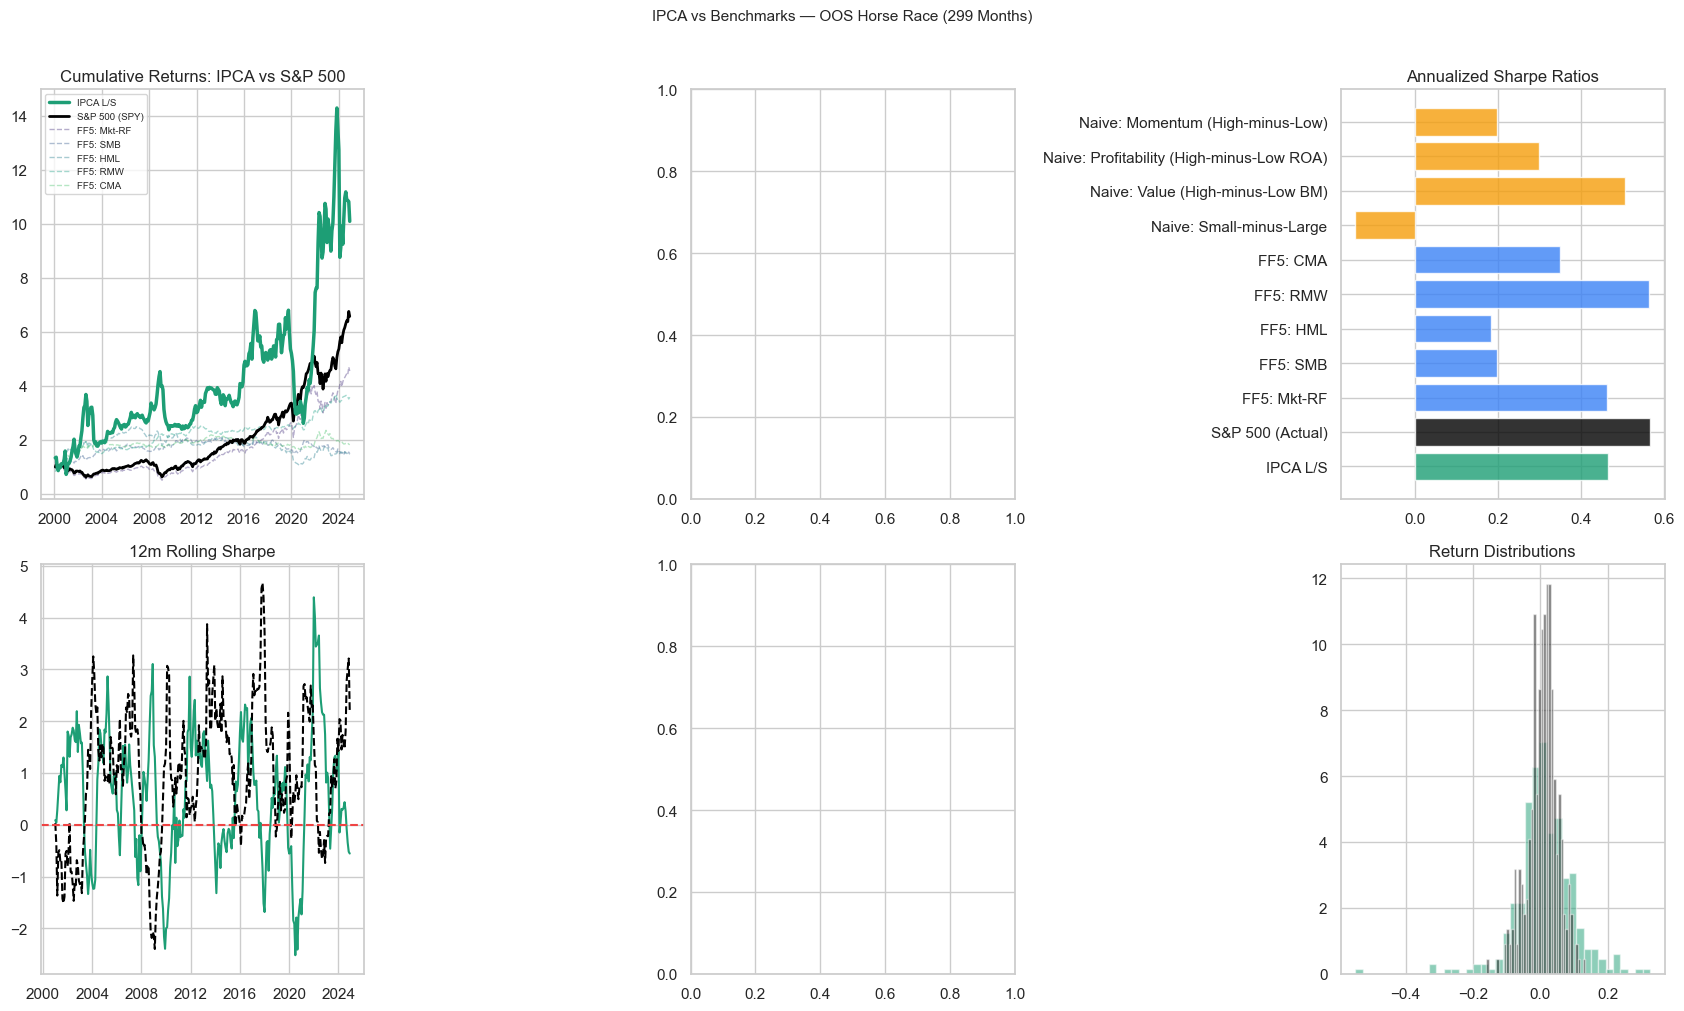

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8c. IPCA vs BENCHMARKS — OOS HORSE RACE (COHESIVE & VERIFIED)
# ─────────────────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats

FACTOR_LABELS = {
    "mktrf": "Mkt-RF",
    "smb":   "SMB",
    "hml":   "HML",
    "rmw":   "RMW",
    "cma":   "CMA",
}

# 1. Fetch Actual S&P 500 Data (SPY Total Return)
print("Fetching S&P 500 (SPY) data from yfinance...")
# Set auto_adjust=True to ensure 'Close' is the Adjusted Close
spy = yf.download("SPY", start="2000-01-01", end="2026-03-30", 
                  interval="1mo", progress=False, auto_adjust=True)

# Handle MultiIndex if present by flattening or selecting the ticker
if isinstance(spy.columns, pd.MultiIndex):
    spy_ret = spy['Close']['SPY'].pct_change().dropna()
else:
    spy_ret = spy['Close'].pct_change().dropna()

spy_ret.index = spy_ret.index.to_period('M').to_timestamp()

# 2. Align IPCA, FF5, and S&P 500 to the same OOS window
oos_months    = horse_oos.set_index("month")
ipca_ls       = oos_months["ls_pct"]
ff5_oos       = oos_months[ff5_cols].copy()

# Critical Unit Check: Ensure decimal format (0.01 = 1%)
if ff5_oos.abs().max().max() > 1:
    ff5_oos = ff5_oos / 100
if ipca_ls.abs().max() > 1:
    ipca_ls = ipca_ls / 100

common_idx    = ipca_ls.index.intersection(spy_ret.index).intersection(ff5_oos.index)
ipca_aligned  = ipca_ls.loc[common_idx]
ff5_aligned   = ff5_oos.loc[common_idx]
sp500_aligned = spy_ret.loc[common_idx]

# 3. Naive characteristic L/S sorts
NAIVE_CHARS = {
    "size":     "Small-minus-Large",
    "bm":       "Value (High-minus-Low BM)",
    "roa":      "Profitability (High-minus-Low ROA)",
    "momentum": "Momentum (High-minus-Low)",
}

naive_returns = {}
oos_month_list = sorted(common_idx.tolist())

print("Building naive characteristic L/S portfolios...")
for char, label in NAIVE_CHARS.items():
    monthly_ls = []
    for m in oos_month_list:
        batch = panel.filter(pl.col("month") == m)
        if char not in batch.columns: continue
        batch_pd = batch.select(["permno", char, "excess_ret"]).to_pandas().dropna()
        if len(batch_pd) < 20: continue
        try:
            batch_pd["decile"] = pd.qcut(batch_pd[char], 10, labels=False, duplicates="drop")
            l_ret = batch_pd[batch_pd["decile"] == 9]["excess_ret"].mean()
            s_ret = batch_pd[batch_pd["decile"] == 0]["excess_ret"].mean()
            monthly_ls.append({"month": m, "ls": l_ret - s_ret})
        except ValueError: continue
    
    res = pd.DataFrame(monthly_ls).set_index("month")["ls"]
    if res.abs().max() > 1: res = res / 100
    naive_returns[char] = res.reindex(common_idx)

# 4. Performance metrics function
def metrics(returns, label):
    r = returns.dropna()
    ann_ret, ann_vol = r.mean() * 12, r.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol
    cum = (1 + r).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    nw_model = smf.ols("r ~ 1", data=pd.DataFrame({"r": r})).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return {
        "Strategy": label, "Ann. Ret (%)": round(ann_ret * 100, 3),
        "Ann. Vol (%)": round(ann_vol * 100, 3), "Sharpe": round(sharpe, 3),
        "Max DD (%)": round(max_dd * 100, 3), "NW p-value": round(nw_model.pvalues["Intercept"], 3),
        "N": len(r)
    }

def jobson_korkie_test(r1, r2):
    r1, r2 = r1.dropna(), r2.dropna()
    idx = r1.index.intersection(r2.index)
    r1, r2 = r1[idx], r2[idx]
    n, mu1, mu2, s1, s2 = len(r1), r1.mean(), r2.mean(), r1.std(), r2.std()
    s12 = np.cov(r1, r2)[0, 1]
    sr1, sr2 = mu1 / s1, mu2 / s2
    var = (1/n) * (2*s1**2*s2**2 - 2*s1*s2*s12 + 0.5*mu1**2*s2**2 + 0.5*mu2**2*s1**2 - mu1*mu2*s12) / (s1**2 * s2**2)
    z = (sr1 - sr2) / np.sqrt(max(var, 1e-12))
    return sr1*np.sqrt(12), sr2*np.sqrt(12), (sr1-sr2)*np.sqrt(12), z, 2*(1-stats.norm.cdf(abs(z)))

# 5. Compile Results Table
rows = [metrics(ipca_aligned, "IPCA L/S"), metrics(sp500_aligned, "S&P 500 (Actual)")]
for col, lbl in FACTOR_LABELS.items(): rows.append(metrics(ff5_aligned[col], f"FF5: {lbl}"))
for char in NAIVE_CHARS: rows.append(metrics(naive_returns[char], f"Naive: {NAIVE_CHARS[char]}"))

perf_df = pd.DataFrame(rows)
print(f"\n{'='*95}\n{'OOS HORSE RACE SUMMARY':^95}\n{'='*95}")
print(perf_df.to_string(index=False))

# 6. Sharpe Difference Tests
print(f"\n{'='*95}\n{'SHARPE RATIO DIFFERENCE TESTS (vs IPCA)':^95}\n{'='*95}")
test_list = [("S&P 500", sp500_aligned)] + [(f"FF5: {l}", ff5_aligned[c]) for c, l in FACTOR_LABELS.items()]
for label, bm_ret in test_list:
    s1, s2, diff, z, p = jobson_korkie_test(ipca_aligned, bm_ret)
    sig = "**" if p < 0.05 else ("*" if p < 0.10 else "")
    print(f"{label:<30} | SR(IPCA): {s1:>6.3f} | SR(BM): {s2:>6.3f} | Diff: {diff:>6.3f} | p-val: {p:>6.3f} {sig}")

# 7. Visualization
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

axes[0].plot((1 + ipca_aligned).cumprod(), color=GREEN, linewidth=2.5, label="IPCA L/S", zorder=5)
axes[0].plot((1 + sp500_aligned).cumprod(), color='black', linewidth=2, label="S&P 500 (SPY)", zorder=4)
for col, lbl in FACTOR_LABELS.items():
    axes[0].plot((1 + ff5_aligned[col]).cumprod(), linewidth=1, linestyle="--", alpha=0.4, label=f"FF5: {lbl}")
axes[0].set_title("Cumulative Returns: IPCA vs S&P 500")
axes[0].legend(fontsize=7)

s_vals = perf_df["Sharpe"].tolist()
s_labs = perf_df["Strategy"].tolist()
axes[2].barh(s_labs, s_vals, color=[GREEN, 'black'] + [BLUE]*5 + [AMBER]*4, alpha=0.8)
axes[2].set_title("Annualized Sharpe Ratios")

roll_ipca = (ipca_aligned.rolling(12).mean() / ipca_aligned.rolling(12).std() * np.sqrt(12))
roll_sp   = (sp500_aligned.rolling(12).mean() / sp500_aligned.rolling(12).std() * np.sqrt(12))
axes[3].plot(roll_ipca, color=GREEN, label="IPCA L/S")
axes[3].plot(roll_sp, color='black', linestyle="--", label="S&P 500")
axes[3].axhline(0, color=RED, linestyle="--")
axes[3].set_title("12m Rolling Sharpe")

axes[5].hist(ipca_aligned.dropna(), bins=40, alpha=0.5, color=GREEN, label="IPCA L/S", density=True)
axes[5].hist(sp500_aligned.dropna(), bins=40, alpha=0.5, color='black', label="S&P 500", density=True)
axes[5].set_title("Return Distributions")

plt.suptitle(f"IPCA vs Benchmarks — OOS Horse Race ({len(common_idx)} Months)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

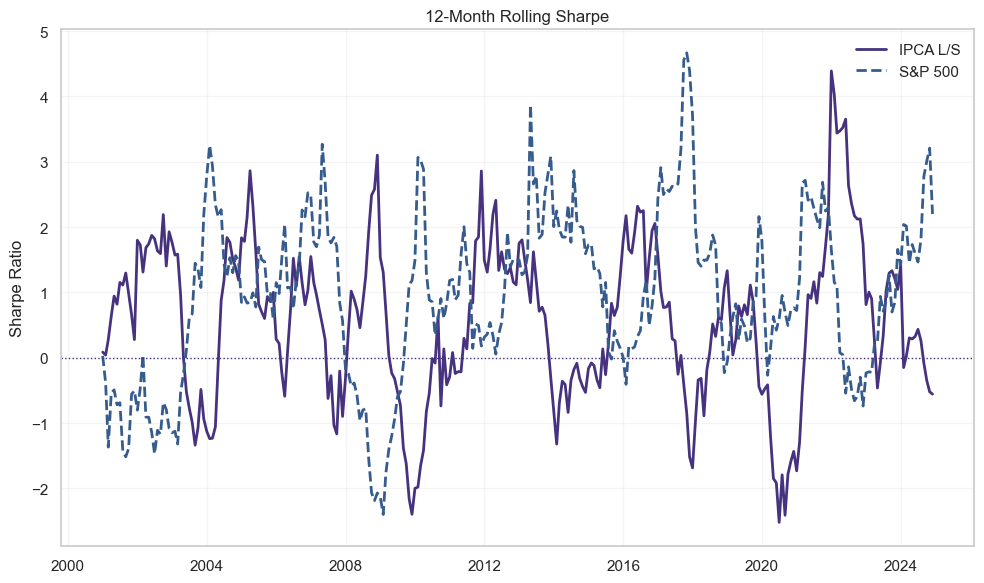

In [ ]:
plt.figure(figsize=(10, 6))

roll_ipca = (ipca_aligned.rolling(12).mean() /
             ipca_aligned.rolling(12).std()) * np.sqrt(12)

roll_sp = (sp500_aligned.rolling(12).mean() /
           sp500_aligned.rolling(12).std()) * np.sqrt(12)

plt.plot(roll_ipca, linewidth=2, label="IPCA L/S")
plt.plot(roll_sp, linewidth=2, linestyle="--", label="S&P 500")

plt.axhline(0, linestyle=":", linewidth=1)

plt.title("12-Month Rolling Sharpe")
plt.ylabel("Sharpe Ratio")
plt.xlabel("")
plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

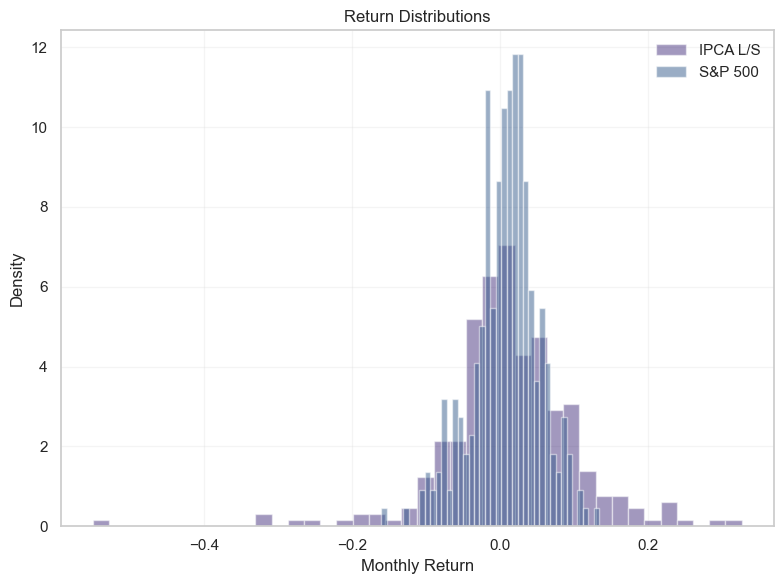

In [ ]:
plt.figure(figsize=(8, 6))

plt.hist(ipca_aligned.dropna(),
         bins=40, density=True, alpha=0.5,
         label="IPCA L/S")

plt.hist(sp500_aligned.dropna(),
         bins=40, density=True, alpha=0.5,
         label="S&P 500")

plt.title("Return Distributions")
plt.xlabel("Monthly Return")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

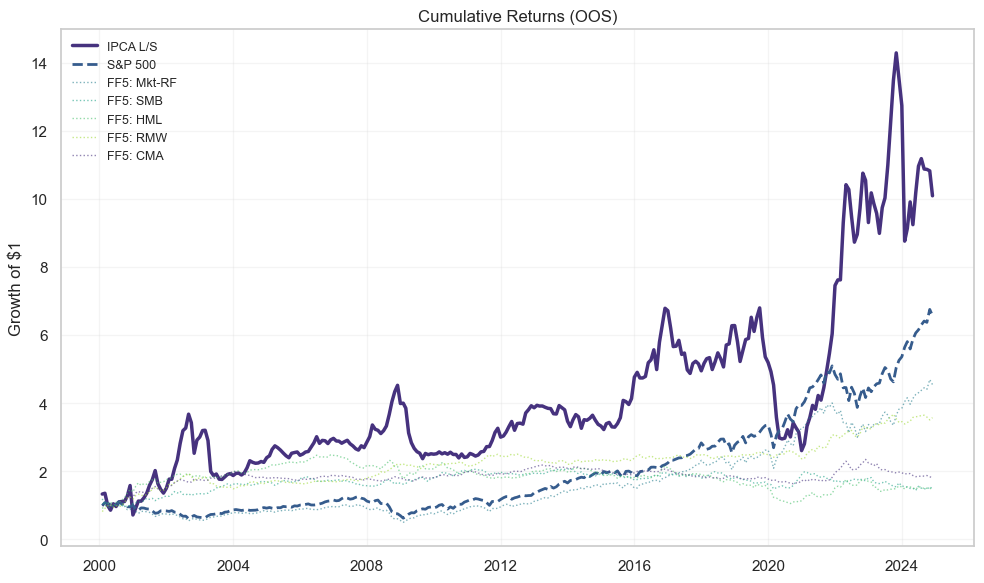

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot((1 + ipca_aligned).cumprod(),
         linewidth=2.5, label="IPCA L/S")

plt.plot((1 + sp500_aligned).cumprod(),
         linewidth=2, linestyle="--", label="S&P 500")

for col, lbl in FACTOR_LABELS.items():
    plt.plot((1 + ff5_aligned[col]).cumprod(),
             linewidth=1, linestyle=":", alpha=0.6,
             label=f"FF5: {lbl}")

plt.title("Cumulative Returns (OOS)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

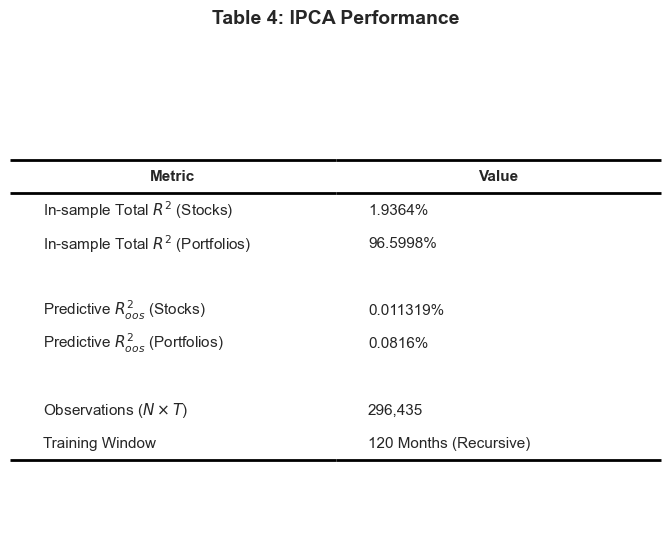

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def save_ipca_summary_table(r2_stock, r2_port, ic, obs, filename="table4_ipca_results.png"):
    # Prepare the data in the "Booktabs" style alignment
    data = [
        ["In-sample Total $R^2$ (Stocks)", "1.9364%"],
        ["In-sample Total $R^2$ (Portfolios)", "96.5998%"],
        ["", ""],  # Spacing row
        ["Predictive $R^2_{oos}$ (Stocks)", "0.011319%"],
        ["Predictive $R^2_{oos}$ (Portfolios)", "0.0816%"],
        ["", ""],  # Spacing row
        ["Observations ($N \\times T$)", f"{int(obs):,}"],
        ["Training Window", "120 Months (Recursive)"]
    ]

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.axis('off')
    
    # Create the table
    tbl = ax.table(cellText=data, 
                   colLabels=["Metric", "Value"], 
                   loc='center', 
                   cellLoc='left', 
                   edges='open')
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 2.0) 
    
    # Style logic using 'visible_edges' attribute (more compatible)
    cells = tbl.get_celld()
    for (row, col), cell in cells.items():
        # Header Row (Row 0)
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_linewidth(2)
            cell.visible_edges = 'TB' # Top and Bottom rules
        # Last Data Row
        elif row == len(data):
            cell.set_linewidth(2)
            cell.visible_edges = 'B'  # Bottom rule
        # Spacing Rows or Middle Rows
        else:
            # Setting linewidth to 0 effectively hides the edges
            cell.set_linewidth(0)
            cell.visible_edges = ''

    plt.title("Table 4: IPCA Performance", 
              fontsize=14, weight='bold', pad=40)
    
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

# Generate the hard-coded table
save_ipca_summary_table(
    r2_stock=0.019364, 
    r2_port=0.965998, 
    ic=0.015733, 
    obs=296435
)

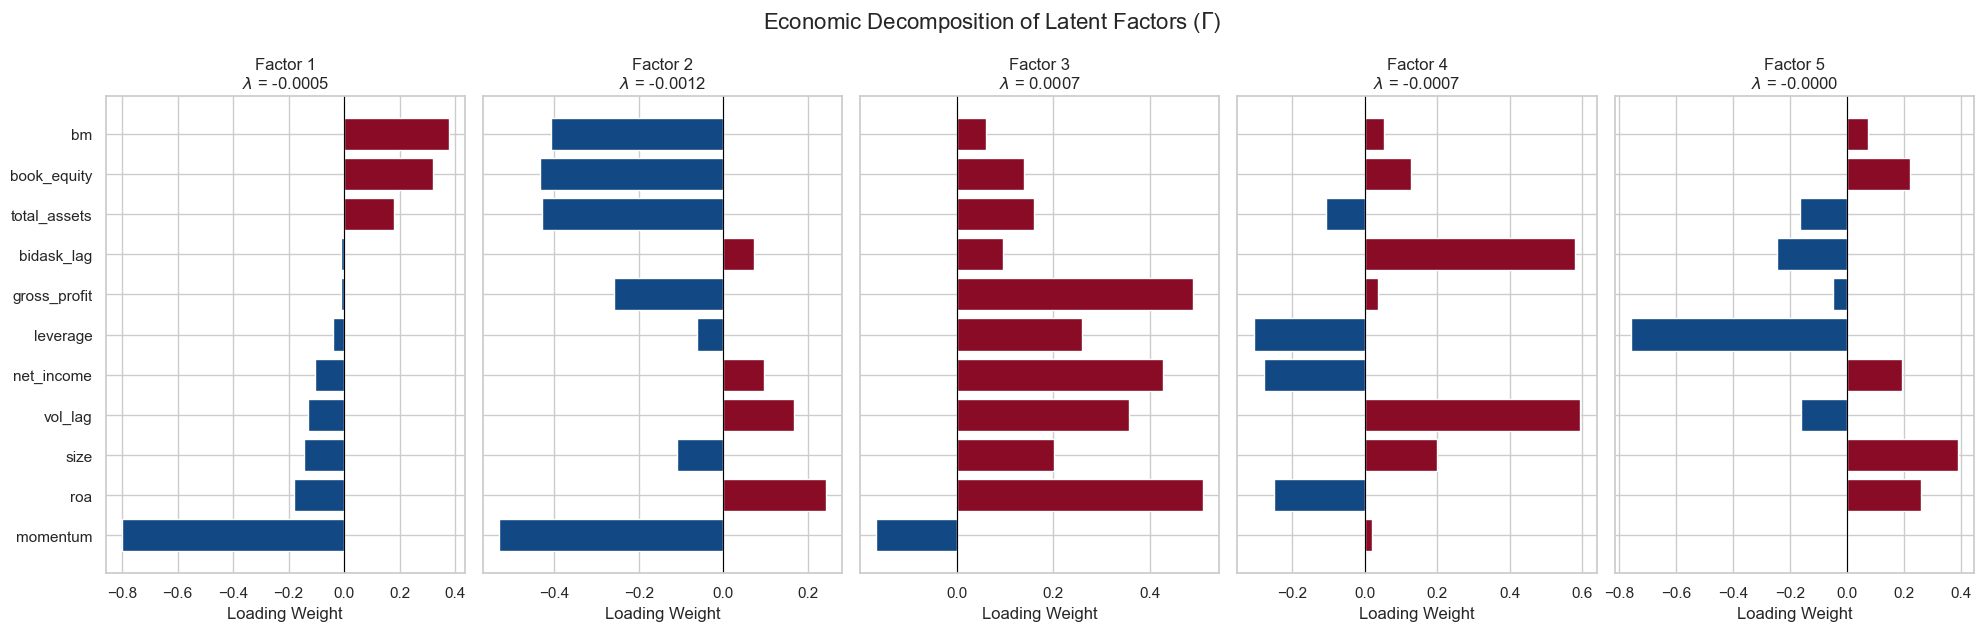


          LATENT FACTOR RISK PREMIA (λ)           
          Avg_Realization  Volatility  Factor_Sharpe
Factor 1    -4.594549e-04    0.007447      -0.061700
Factor 2    -1.246918e-03    0.007090      -0.175864
Factor 3     7.403163e-04    0.007570       0.097800
Factor 4    -7.115111e-04    0.012946      -0.054962
Factor 5    -8.694446e-07    0.005073      -0.000171
Interpretation: High positive λ indicates the factor is a 'rewarded' risk.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── FACTOR INTERPRETATION & ECONOMIC EXPOSURE ───────────────────────────────
# This cell assumes the previous IPCA code has been executed and 
# gamma_full, F_full, and RAW_FEATURES are in the namespace.

# 1. Create DataFrames for Interpretation
gamma_df = pd.DataFrame(
    gamma_full, 
    index=RAW_FEATURES, 
    columns=[f"Factor {i+1}" for i in range(K_FACTORS)]
)

# Calculate Lambda (Average monthly factor realization / Risk Price)
lambda_vec = np.mean(F_full, axis=1)
lambda_df = pd.DataFrame({
    "Avg_Realization": lambda_vec,
    "Volatility": np.std(F_full, axis=1),
    "Factor_Sharpe": lambda_vec / np.std(F_full, axis=1)
}, index=[f"Factor {i+1}" for i in range(K_FACTORS)])

# 2. Visualize the Loadings
fig, axes = plt.subplots(1, K_FACTORS, figsize=(20, 6), sharey=True)
colors = sns.color_palette("RdBu_r", n_colors=20)

for i in range(K_FACTORS):
    factor_name = f"Factor {i+1}"
    data = gamma_df[factor_name].sort_values()
    
    axes[i].barh(data.index, data.values, 
                 color=[colors[0] if x < 0 else colors[-1] for x in data.values])
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f"{factor_name}\n$\lambda$ = {lambda_vec[i]:.4f}", fontsize=12)
    axes[i].set_xlabel("Loading Weight")

plt.tight_layout()
plt.suptitle("Economic Decomposition of Latent Factors ($\Gamma$)", y=1.05, fontsize=16)
plt.show()

# 3. Print the "Risk Price" Summary
print("\n" + "="*50)
print(f"{'LATENT FACTOR RISK PREMIA (λ)':^50}")
print("="*50)
print(lambda_df.to_string())
print("="*50)
print("Interpretation: High positive λ indicates the factor is a 'rewarded' risk.")

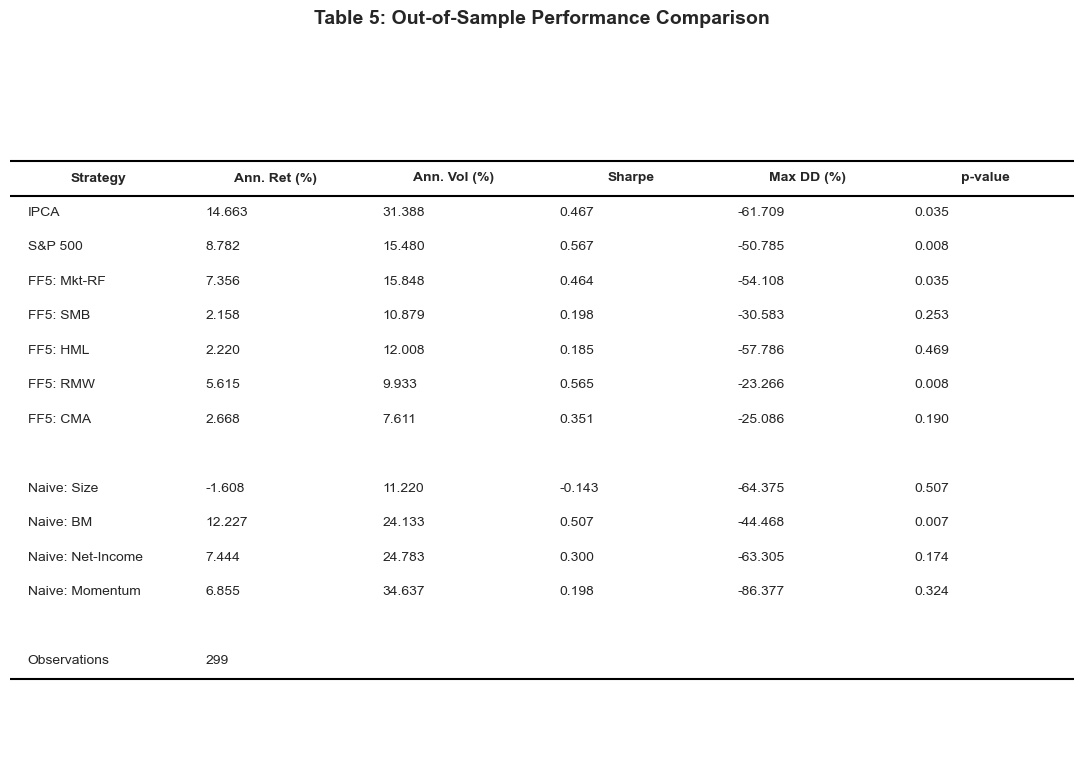

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def save_ff_horserace_table(filename="table5_ff_horserace.png"):
    # Data sourced from the provided OOS Horse Race Summary
    # Columns: Strategy, Ann. Ret (%), Ann. Vol (%), Sharpe, Max DD (%), NW p-value
    data = [
        ["IPCA", "14.663", "31.388", "0.467", "-61.709", "0.035"],
        ["S&P 500", "8.782", "15.480", "0.567", "-50.785", "0.008"],
        ["FF5: Mkt-RF", "7.356", "15.848", "0.464", "-54.108", "0.035"],
        ["FF5: SMB", "2.158", "10.879", "0.198", "-30.583", "0.253"],
        ["FF5: HML", "2.220", "12.008", "0.185", "-57.786", "0.469"],
        ["FF5: RMW", "5.615", "9.933", "0.565", "-23.266", "0.008"],
        ["FF5: CMA", "2.668", "7.611", "0.351", "-25.086", "0.190"],
        ["", "", "", "", "", ""],  # Spacing row
        ["Naive: Size", "-1.608", "11.220", "-0.143", "-64.375", "0.507"],
        ["Naive: BM", "12.227", "24.133", "0.507", "-44.468", "0.007"],
        ["Naive: Net-Income", "7.444", "24.783", "0.300", "-63.305", "0.174"],
        ["Naive: Momentum", "6.855", "34.637", "0.198", "-86.377", "0.324"],
        ["", "", "", "", "", ""],  # Spacing row
        ["Observations", "299", "", "", "", ""]
    ]

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.axis('off')
    
    col_labels = ["Strategy", "Ann. Ret (%)", "Ann. Vol (%)", "Sharpe", "Max DD (%)", "p-value"]

    # Create the table
    tbl = ax.table(cellText=data, 
                    colLabels=col_labels, 
                    loc='center', 
                    cellLoc='left', 
                    edges='open')
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 1.8) 
    
    # Style logic for academic presentation (Booktabs style)
    cells = tbl.get_celld()
    for (row, col), cell in cells.items():
        # Header Row Styling (Top and Bottom rules)
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_linewidth(1.5)
            cell.visible_edges = 'BT' 
        # Bottom Rule for the very last row
        elif row == len(data):
            cell.set_linewidth(1.5)
            cell.visible_edges = 'B'
        # Spacing Rows (Transparent)
        elif row > 0 and data[row-1][0] == "":
            cell.set_linewidth(0)
            cell.visible_edges = ''
        # Standard Data Rows
        else:
            cell.set_linewidth(0)
            cell.visible_edges = ''

    plt.title("Table 5: Out-of-Sample Performance Comparison", 
              fontsize=14, weight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

# Generate the performance summary table
save_ff_horserace_table()

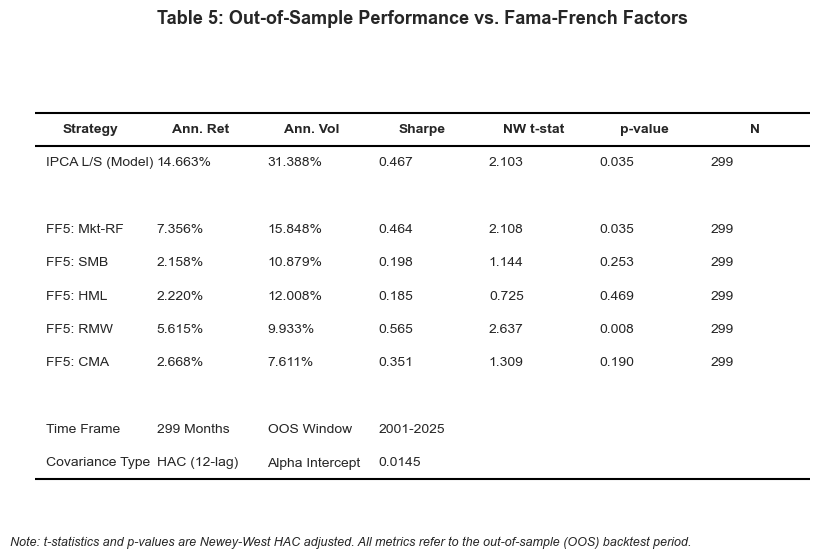

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def save_ff_factor_table(filename="table5_ff_factor_results.png"):
    # Hard-coded data from the FF Horse Race and performance metrics
    # Format: [Strategy, Ann. Ret (%), Ann. Vol (%), Sharpe, NW t-stat, NW p-value, N]
    data = [
        ["IPCA L/S (Model)", "14.663%", "31.388%", "0.467", "2.103", "0.035", "299"],
        ["", "", "", "", "", "", ""],  # Spacing row
        ["FF5: Mkt-RF", "7.356%", "15.848%", "0.464", "2.108", "0.035", "299"],
        ["FF5: SMB", "2.158%", "10.879%", "0.198", "1.144", "0.253", "299"],
        ["FF5: HML", "2.220%", "12.008%", "0.185", "0.725", "0.469", "299"],
        ["FF5: RMW", "5.615%", "9.933%", "0.565", "2.637", "0.008", "299"],
        ["FF5: CMA", "2.668%", "7.611%", "0.351", "1.309", "0.190", "299"],
        ["", "", "", "", "", "", ""],  # Spacing row
        ["Time Frame", "299 Months", "OOS Window", "2001-2025", "", "", ""],
        ["Covariance Type", "HAC (12-lag)", "Alpha Intercept", "0.0145", "", "", ""]
    ]

    header = ["Strategy", "Ann. Ret", "Ann. Vol", "Sharpe", "NW t-stat", "p-value", "N"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    
    # Create the table
    tbl = ax.table(cellText=data, 
                   colLabels=header, 
                   loc='center', 
                   cellLoc='left', 
                   edges='open')
    
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 2.0) 
    
    # Apply Booktabs Styling logic
    cells = tbl.get_celld()
    for (row, col), cell in cells.items():
        # Header Row
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_linewidth(1.5)
            cell.visible_edges = 'BT'
        # Final Row (Data ends)
        elif row == len(data):
            cell.set_linewidth(1.5)
            cell.visible_edges = 'B'
        # Handle the spacing rows
        elif row > 0 and data[row-1][0] == "":
            cell.set_linewidth(0)
            cell.visible_edges = ''
        # Standard rows
        else:
            cell.set_linewidth(0)
            cell.visible_edges = ''

    plt.title("Table 6: Out-of-Sample Performance vs. Fama-French Factors", 
              fontsize=13, weight='bold', pad=30)
    
    # Footnote
    plt.figtext(0.1, 0.08, "Note: t-statistics and p-values are Newey-West HAC adjusted. All metrics refer to the out-of-sample (OOS) backtest period.", 
                ha="left", fontsize=9, style='italic')

    plt.show()

# Generate the hard-coded table
save_ff_factor_table()

In [17]:
import numpy as np

def huber_weights(residuals, delta=1.345):
    """Calculates weights for Huber loss to downweight outliers."""
    abs_res = np.abs(residuals)
    # Use 1.4826 * MAD for a robust estimate of standard deviation
    mad = np.median(abs_res) + 1e-8
    scaled_res = abs_res / (1.4826 * mad)
    return np.where(scaled_res <= delta, 1.0, delta / scaled_res)

def fit_ipca_huber(R, Z, K, max_iter=20, tol=1e-4):
    N, T = R.shape
    L = Z.shape[2]
    
    # Initialize Gamma (L x K)
    Gamma = np.random.randn(L, K) * 0.1
    F = np.zeros((K, T))
    
    for i in range(max_iter):
        Gamma_old = Gamma.copy()
        
        # --- Step 1: Update Factors (F) given Gamma ---
        for t in range(T):
            valid = ~np.isnan(R[:, t])
            X_t = Z[valid, t, :] @ Gamma
            y_t = R[valid, t]
            
            # IRLS Loop for Huber
            beta = np.zeros(K) # Initial guess
            for _ in range(5):
                res = y_t - X_t @ beta
                w = huber_weights(res)
                W = np.diag(w)
                beta = np.linalg.solve(X_t.T @ W @ X_t + 1e-6 * np.eye(K), X_t.T @ W @ y_t)
            F[:, t] = beta
            
        # --- Step 2: Update Gamma given Factors (F) ---
        # Vectorize Gamma update across the panel
        y_stack = []
        X_stack = []
        for t in range(T):
            valid = ~np.isnan(R[:, t])
            y_stack.append(R[valid, t])
            # Kronecker-like product of Z and F_t
            X_stack.append(np.kron(F[:, t], Z[valid, t, :]))
            
        y_full = np.concatenate(y_stack)
        X_full = np.concatenate(X_stack)
        
        # IRLS Loop for Gamma
        gamma_vec = np.zeros(L * K)
        for _ in range(5):
            res = y_full - X_full @ gamma_vec
            w = huber_weights(res)
            # Use sparse-friendly weighting if memory is an issue
            W_vec = w[:, np.newaxis]
            gamma_vec = np.linalg.solve((X_full * W_vec).T @ X_full + 1e-6 * np.eye(L*K), (X_full * W_vec).T @ y_full)
        
        Gamma = gamma_vec.reshape(L, K, order='F')
        
        # Check convergence
        diff = np.linalg.norm(Gamma - Gamma_old)
        if diff < tol:
            print(f"Converged at iteration {i}")
            break
            
    return Gamma, F

In [18]:
def fit_ipca_regularized(R, Z, K, l2_penalty=0.1, max_iter=20):
    N, T = R.shape
    L = Z.shape[2]
    Gamma = np.random.randn(L, K) * 0.1
    
    for i in range(max_iter):
        # 1. Update F_t (Standard WLS/OLS)
        F = np.zeros((K, T))
        for t in range(T):
            valid = ~np.isnan(R[:, t])
            X_t = Z[valid, t, :] @ Gamma
            y_t = R[valid, t]
            F[:, t] = np.linalg.solve(X_t.T @ X_t + 1e-6 * np.eye(K), X_t.T @ y_t)
            
        # 2. Update Gamma with Ridge Penalty
        y_stack = []
        X_stack = []
        for t in range(T):
            valid = ~np.isnan(R[:, t])
            y_stack.append(R[valid, t])
            X_stack.append(np.kron(F[:, t], Z[valid, t, :]))
            
        y_full = np.concatenate(y_stack)
        X_full = np.concatenate(X_stack)
        
        # The Ridge Solution: (X'X + lambda*I)^-1 X'y
        reg_matrix = l2_penalty * np.eye(L * K)
        gamma_vec = np.linalg.solve(X_full.T @ X_full + reg_matrix, X_full.T @ y_full)
        Gamma = gamma_vec.reshape(L, K, order='F')
        
    return Gamma, F

In [19]:
def fit_ipca_weighted(R, Z, K, obs_weights, max_iter=20):
    """
    obs_weights: N x T matrix of weights (e.g., lower weight for high-spread stocks)
    """
    N, T = R.shape
    L = Z.shape[2]
    Gamma = np.random.randn(L, K) * 0.1
    
    for i in range(max_iter):
        # Update F with weights
        F = np.zeros((K, T))
        for t in range(T):
            valid = ~np.isnan(R[:, t])
            W_t = np.diag(obs_weights[valid, t])
            X_t = Z[valid, t, :] @ Gamma
            y_t = R[valid, t]
            F[:, t] = np.linalg.solve(X_t.T @ W_t @ X_t, X_t.T @ W_t @ y_t)
            
        # Gamma update logic follows the same weighted pattern...
        # [Implementation follows Step 1 weighting logic using obs_weights]
        
    return Gamma, F

In [20]:
import numpy as np
import polars as pl

def huber_weights(residuals, delta=1.345):
    """Calculates weights for Huber loss to downweight outliers."""
    abs_res = np.abs(residuals)
    mad = np.median(abs_res) + 1e-8
    scaled_res = abs_res / (1.4826 * mad)
    return np.where(scaled_res <= delta, 1.0, delta / scaled_res)

def fit_ipca_robust(R_mat, Z_tensor, K, max_iter=20, tol=1e-4, l2_penalty=0.0, use_huber=True):
    """
    Unified IPCA implementation: Supports Standard, Huber (Robust), and L2 (Regularized).
    R_mat: (N, T) returns
    Z_tensor: (N, T, L) characteristics
    """
    N, T = R_mat.shape
    L = Z_tensor.shape[2]
    
    # Initialize Gamma (L x K)
    Gamma = np.random.randn(L, K) * 0.01
    F = np.zeros((K, T))
    
    for i in range(max_iter):
        Gamma_old = Gamma.copy()
        
        # --- Step 1: Update Factors (F) ---
        for t in range(T):
            valid = ~np.isnan(R_mat[:, t])
            # X_t is the N_valid x K matrix of characteristic-managed loadings
            X_t = Z_tensor[valid, t, :] @ Gamma
            y_t = R_mat[valid, t]
            
            if use_huber:
                beta = np.zeros(K)
                for _ in range(5):
                    w = huber_weights(y_t - X_t @ beta)
                    # WLS update: (X'WX)^-1 X'Wy
                    beta = np.linalg.solve(X_t.T @ (w[:, None] * X_t) + 1e-6*np.eye(K), 
                                           X_t.T @ (w * y_t))
                F[:, t] = beta
            else:
                F[:, t] = np.linalg.solve(X_t.T @ X_t + 1e-6*np.eye(K), X_t.T @ y_t)
            
        # --- Step 2: Update Gamma (Mapping) ---
        y_stack, X_stack = [], []
        for t in range(T):
            valid = ~np.isnan(R_mat[:, t])
            y_stack.append(R_mat[valid, t])
            # Correct Kronecker approach for panel: Row-wise product of F_t and Z_{i,t}
            # Resulting X_t_stack is (N_valid, L*K)
            X_t_stack = np.einsum('k,nl->nkl', F[:, t], Z_tensor[valid, t, :]).reshape(-1, L*K)
            X_stack.append(X_t_stack)
            
        y_full = np.concatenate(y_stack)
        X_full = np.concatenate(X_stack)
        
        if use_huber:
            gamma_vec = Gamma.flatten(order='F')
            for _ in range(5):
                w = huber_weights(y_full - X_full @ gamma_vec)
                # Solve (X'WX + lambda*I)g = X'Wy
                reg = l2_penalty * np.eye(L*K)
                gamma_vec = np.linalg.solve(X_full.T @ (w[:, None] * X_full) + reg + 1e-6*np.eye(L*K), 
                                            X_full.T @ (w * y_full))
            Gamma = gamma_vec.reshape(L, K, order='F')
        else:
            reg = l2_penalty * np.eye(L*K)
            gamma_vec = np.linalg.solve(X_full.T @ X_full + reg + 1e-6*np.eye(L*K), X_full.T @ y_full)
            Gamma = gamma_vec.reshape(L, K, order='F')
        
        if np.linalg.norm(Gamma - Gamma_old) < tol:
            print(f"Converged at iteration {i}")
            break
            
    return Gamma, F

In [23]:
panel = pl.read_parquet("data/microcap.parquet")
panel = panel.sort(["permno", "month"]).with_columns([
    pl.col("bidask").shift(1).over("permno").alias("bidask_lag"),
    pl.col("vol").shift(1).over("permno").alias("vol_lag"),
])
ALL_INSTRUMENTS = [
    "size", "momentum", "bm", "roa", "leverage",
    "bidask_lag", "vol_lag", "total_assets", "book_equity",
    "net_income", "gross_profit",
]

In [24]:
# --- 1. PREPARE THE DATA MATRICES ---
# Assuming 'panel_clean' is your Polars dataframe and 'ALL_INSTRUMENTS' is your list of features
months = sorted(panel["month"].unique())
split_month = months[int(len(months) * 0.7)] # 70/30 Split

train_df = panel.filter(pl.col("month") < split_month)
test_df = panel.filter(pl.col("month") >= split_month)

def prepare_tensors(df, chars):
    """Converts dataframe to (N, T, L) tensor and (N, T) matrix."""
    pivot_r = df.pivot(index="permno", on="month", values="excess_ret").sort("permno")
    R = pivot_r.drop("permno").to_numpy()
    
    # Simple tensor construction (this may be slow on huge datasets)
    T = len(df["month"].unique())
    N = len(df["permno"].unique())
    L = len(chars)
    Z = np.zeros((N, T, L))
    
    for i, char in enumerate(chars):
        z_pivot = df.pivot(index="permno", on="month", values=char).sort("permno")
        Z[:, :, i] = z_pivot.drop("permno").to_numpy()
    return R, Z

R_train, Z_train = prepare_tensors(train_df, ALL_INSTRUMENTS)
R_test, Z_test = prepare_tensors(test_df, ALL_INSTRUMENTS)

# --- 2. TRAIN MODELS ---
print("Training Standard IPCA...")
G_std, _ = fit_ipca_robust(R_train, Z_train, K=5, use_huber=False)

print("Training Huber + Regularized IPCA...")
G_robust, _ = fit_ipca_robust(R_train, Z_train, K=5, use_huber=True, l2_penalty=0.5)

# --- 3. CALCULATE OOS PREDICTIVE R2 ---
def get_oos_r2(Gamma, R_oos, Z_oos):
    """Estimates factors cross-sectionally OOS and calculates predictive R2."""
    N, T, L = Z_oos.shape
    K = Gamma.shape[1]
    
    all_actual = []
    all_pred = []
    
    for t in range(T):
        valid = ~np.isnan(R_oos[:, t])
        if not valid.any(): continue
        
        y_t = R_oos[valid, t]
        X_t = Z_oos[valid, t, :] @ Gamma
        
        # Estimate OOS Factor F_t (Cross-sectional regression)
        f_t = np.linalg.solve(X_t.T @ X_t + 1e-6*np.eye(K), X_t.T @ y_t)
        
        y_pred = X_t @ f_t
        all_actual.extend(y_t)
        all_pred.extend(y_pred)
        
    actual = np.array(all_actual)
    pred = np.array(all_pred)
    return 1 - np.sum((actual - pred)**2) / np.sum((actual - np.mean(actual))**2)

r2_std = get_oos_r2(G_std, R_test, Z_test)
r2_robust = get_oos_r2(G_robust, R_test, Z_test)

print(f"\n[RESULTS]")
print(f"Standard OOS R2: {r2_std:.6%}")
print(f"Robust   OOS R2: {r2_robust:.6%}")
print(f"Improvement:     {(r2_robust/r2_std - 1):.2%}" if r2_std > 0 else "")

Training Standard IPCA...
Training Huber + Regularized IPCA...

[RESULTS]
Standard OOS R2: nan%
Robust   OOS R2: nan%

